<a href="https://colab.research.google.com/github/ElenaEkb/portfolio-tender-analysis/blob/main/Murmansc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from collections import Counter
from wordcloud import WordCloud
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

Произведем предварительный просмотр данных. Сначала загрузим файл с помощью библиотеки Pandas и посмотрим первые несколько строк, чтобы понять структуру данных.

In [ ]:
ds = pd.read_csv('Murmansc.csv', encoding='windows-1251', sep=';', decimal=',')
ds.head(5)

,Номер реестровой записи контракта,Заказчик: наименование,Заказчик: ИНН,Заказчик: КПП,Уровень бюджета,Источник финансирования контракта: наименование бюджета,Источник финансирования контракта: наименование/вид внебюджетных средств,Способ размещения заказа,Номер извещения о проведени торгов,"Дата подведения результатов определения поставщика (подрядчика, исполнителя)",...,"Объект закупки: наименование товаров, работ, услуг",Объект закупки: код позиции,"Объект закупки: цена за единицу, рублей","Объект закупки: количество поставленных товаров, выполненных работ, оказанных услуг","Объект закупки: сумма, рублей","Информация о поставщиках (исполнителях, подрядчиках) по контракту: наименование юридического лица (ф.и.о. физического лица)","Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН","Информация о поставщиках (исполнителях, подрядчиках) по контракту: КПП",Дата последнего изменения записи,Дата исполнения контракта: по контракту
0,'3510120082325000020',МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ ГОРОДА АПАТИ...,'5101200823','511801001',Местный бюджет,Бюджет города Апатиты с подведомственной терри...,NaN,Электронный аукцион,'0349300001725000092',18.07.2025,...,Выполнение работ по содержанию улично-дорожной...,42.11.20.300,'60611200.33 ','1','60611200.33',"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПРОФ...",'5101313351','511801001',03.07.2026 18:35,24.10.2028
1,'3510120082325000020',МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ ГОРОДА АПАТИ...,'5101200823','511801001',Местный бюджет,Бюджет города Апатиты с подведомственной терри...,NaN,Электронный аукцион,'0349300001725000092',18.07.2025,...,Выполнение работ по содержанию улично-дорожной...,42.11.20.300,'80324723.47 ','1','80324723.47',"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПРОФ...",'5101313351','511801001',03.07.2026 18:35,24.10.2028
2,'3510120082325000020',МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ ГОРОДА АПАТИ...,'5101200823','511801001',Местный бюджет,Бюджет города Апатиты с подведомственной терри...,NaN,Электронный аукцион,'0349300001725000092',18.07.2025,...,Выполнение работ по содержанию улично-дорожной...,42.11.20.300,'99755219.45 ','1','99755219.45',"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ПРОФ...",'5101313351','511801001',03.07.2026 18:35,24.10.2028
3,'3510791316125000094',"МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ ""УПРАВЛЕНИЕ ...",'5107913161','510701001',Местный бюджет,Бюджет города Мончегорска,NaN,Электронный аукцион,'0349300057125000180',11.12.2025,...,Содержание улично-дорожной сети и элементов до...,42.11.20.300,'128061431.00 ','1','128061431.00',"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГОРО...",'5108005564','510801001',03.07.2026 17:31,31.12.2026
4,'3510503279226000018',"МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ ""ХОЗЯЙСТВЕНН...",'5105032792','510501001',Местный бюджет,Бюджет Кольского муниципального округа,NaN,Электронный аукцион,'0149200002326000975',16.03.2026,...,Камера видеонаблюдения. Товарный знак: АйТек ПРО,26.70.13.000-00000008,'69387.82 ','5','346939.10',КРЕЩЕНЕЦКИЙ АЛЕКСАНДРОВИЧ ИГОРЬ,'510516089796','',03.07.2026 16:02,13.10.2026


Используя метод info(), мы можем получить больше информации о наборе данных, включая имена всех столбцов и соответствующие им типы данных, а также количество непропущенных значений.

In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 645 entries, 0 to 644
Data columns (total 29 columns):
 #   Column                                                                                                                       Non-Null Count  Dtype  
---  ------                                                                                                                       --------------  -----  
 0   Номер реестровой записи контракта                                                                                            645 non-null    object 
 1   Заказчик: наименование                                                                                                       645 non-null    object 
 2   Заказчик: ИНН                                                                                                                645 non-null    object 
 3   Заказчик: КПП                                                                                                           

In [ ]:
# Проверка наличия дубликатов по всему датафрейму
duplicates = ds.duplicated()
print(f'Количество дубликатов: {sum(duplicates)}')

Количество дубликатов: 0


In [ ]:
ds.describe(include='all')

,Номер реестровой записи контракта,Заказчик: наименование,Заказчик: ИНН,Заказчик: КПП,Уровень бюджета,Источник финансирования контракта: наименование бюджета,Источник финансирования контракта: наименование/вид внебюджетных средств,Способ размещения заказа,Номер извещения о проведени торгов,"Дата подведения результатов определения поставщика (подрядчика, исполнителя)",...,"Объект закупки: наименование товаров, работ, услуг",Объект закупки: код позиции,"Объект закупки: цена за единицу, рублей","Объект закупки: количество поставленных товаров, выполненных работ, оказанных услуг","Объект закупки: сумма, рублей","Информация о поставщиках (исполнителях, подрядчиках) по контракту: наименование юридического лица (ф.и.о. физического лица)","Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН","Информация о поставщиках (исполнителях, подрядчиках) по контракту: КПП",Дата последнего изменения записи,Дата исполнения контракта: по контракту
count,645,645,645,645,417,417,228,645,643,643,...,645,645,644,644,645,645,645,645,645,645
unique,271,53,53,16,3,26,4,5,267,137,...,424,25,602,96,616,87,88,35,254,113
top,'3510503279225000023',МУРМАНСКОЕ МУНИЦИПАЛЬНОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ ...,'5190918123','519001001',Местный бюджет,Бюджет ЗАТО Александровск,Средства бюджетных учреждений,Электронный аукцион,'0149200002325001391',19.12.2025,...,Выполнение работ по капитальному ремонту объек...,42.11.20.300,'4038.91 ','1','306181.16',"ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""ГАГАТ""",'5190073236','519001001',23.06.2026 16:46,30.11.2026
freq,38,188,188,340,337,87,221,426,38,57,...,80,268,7,494,6,80,80,219,38,41
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
ds['Способ размещения заказа'].value_counts(normalize=True)

,proportion
Способ размещения заказа,
Электронный аукцион,0.660465
"Электронный аукцион на проведение работ по строительству, реконструкции, кап. ремонту, сносу объекта кап. строительства в соответствии с п. 8 ч. 1 ст. 33 Закона № 44-ФЗ",0.207752
Открытый конкурс в электронной форме,0.089922
"Открытый конкурс в электронной форме на проведение работ по строительству, реконструкции, кап. ремонту, сносу объекта кап. строительства в соответствии с п. 8 ч. 1 ст. 33 Закона № 44-ФЗ",0.038760
"Закупка у единственного поставщика (подрядчика, исполнителя)",0.003101


In [ ]:
(ds['Способ размещения заказа'].value_counts(normalize=True) * 100).round(2).map('{:.2f}%'.format)

,proportion
Способ размещения заказа,
Электронный аукцион,66.05%
"Электронный аукцион на проведение работ по строительству, реконструкции, кап. ремонту, сносу объекта кап. строительства в соответствии с п. 8 ч. 1 ст. 33 Закона № 44-ФЗ",20.78%
Открытый конкурс в электронной форме,8.99%
"Открытый конкурс в электронной форме на проведение работ по строительству, реконструкции, кап. ремонту, сносу объекта кап. строительства в соответствии с п. 8 ч. 1 ст. 33 Закона № 44-ФЗ",3.88%
"Закупка у единственного поставщика (подрядчика, исполнителя)",0.31%


/tmp/ipykernel_6947/3689880962.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


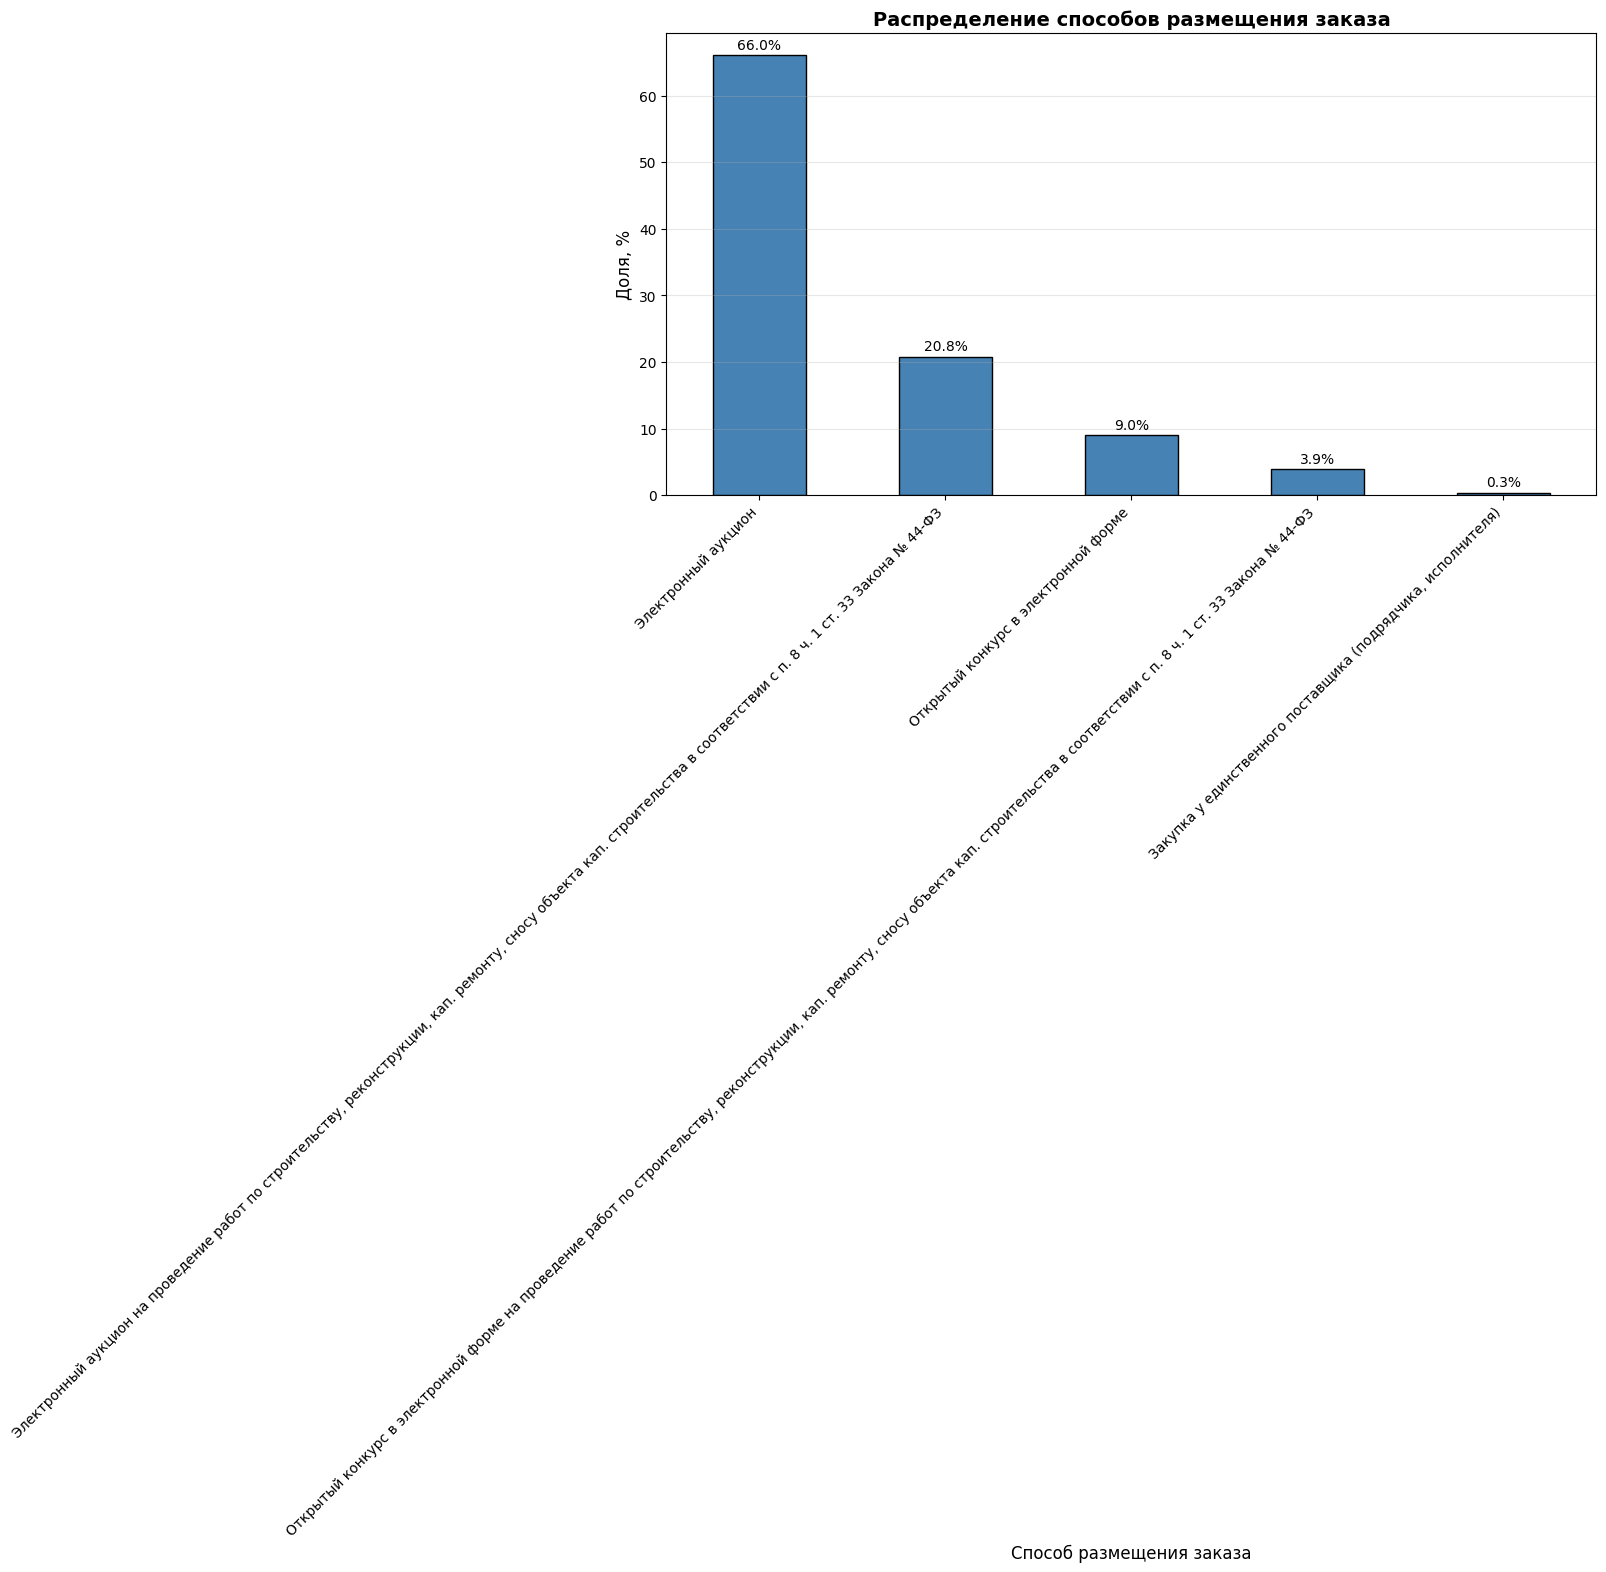

In [ ]:
data_percent = (ds['Способ размещения заказа'].value_counts(normalize=True) * 100).round(2).sort_values(ascending=False)

# Строим гистограмму
fig, ax = plt.subplots(figsize=(12, 6))
bars = data_percent.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')

# Добавляем значения
for i, v in enumerate(data_percent):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=10)

plt.title('Распределение способов размещения заказа', fontsize=14, fontweight='bold')
plt.xlabel('Способ размещения заказа', fontsize=12)
plt.ylabel('Доля, %', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Топ-10 заказчиков с долей в процентах
customer_pct = (ds['Заказчик: наименование'].value_counts(normalize=True) * 100).round(2).head(10)
customer_pct = customer_pct.astype(str) + '%'
print(customer_pct)

Заказчик: наименование
МУРМАНСКОЕ МУНИЦИПАЛЬНОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ "УПРАВЛЕНИЕ ДОРОЖНОГО ХОЗЯЙСТВА"                                                    29.15%
МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ "ОТДЕЛ КАПИТАЛЬНОГО СТРОИТЕЛЬСТВА ЗАТО АЛЕКСАНДРОВСК"                                           13.49%
МУРМАНСКОЕ МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ "УПРАВЛЕНИЕ КАПИТАЛЬНОГО СТРОИТЕЛЬСТВА"                                                9.3%
ГОСУДАРСТВЕННОЕ ОБЛАСТНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ ПО УПРАВЛЕНИЮ АВТОМОБИЛЬНЫМИ ДОРОГАМИ МУРМАНСКОЙ ОБЛАСТИ                             8.84%
МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ "ХОЗЯЙСТВЕННО-ЭКСПЛУАТАЦИОННАЯ СЛУЖБА КОЛЬСКОГО ОКРУГА"                                          7.75%
МУНИЦИПАЛЬНОЕ КАЗЁННОЕ УЧРЕЖДЕНИЕ "УПРАВЛЕНИЕ ЖИЛИЩНО-КОММУНАЛЬНОГО ХОЗЯЙСТВА КОВДОРСКОГО МУНИЦИПАЛЬНОГО ОКРУГА"                   5.89%
МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ "УПРАВЛЕНИЕ БЛАГОУСТРОЙСТВА И РАЗВИТИЯ" ПЕЧЕНГСКОГО МУНИЦИПАЛЬНОГО ОКРУГА МУРМАНСКОЙ ОБЛАСТИ     3.72%
ГОСУДАРСТВЕННОЕ ОБ

/tmp/ipykernel_6947/2062071667.py:35: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


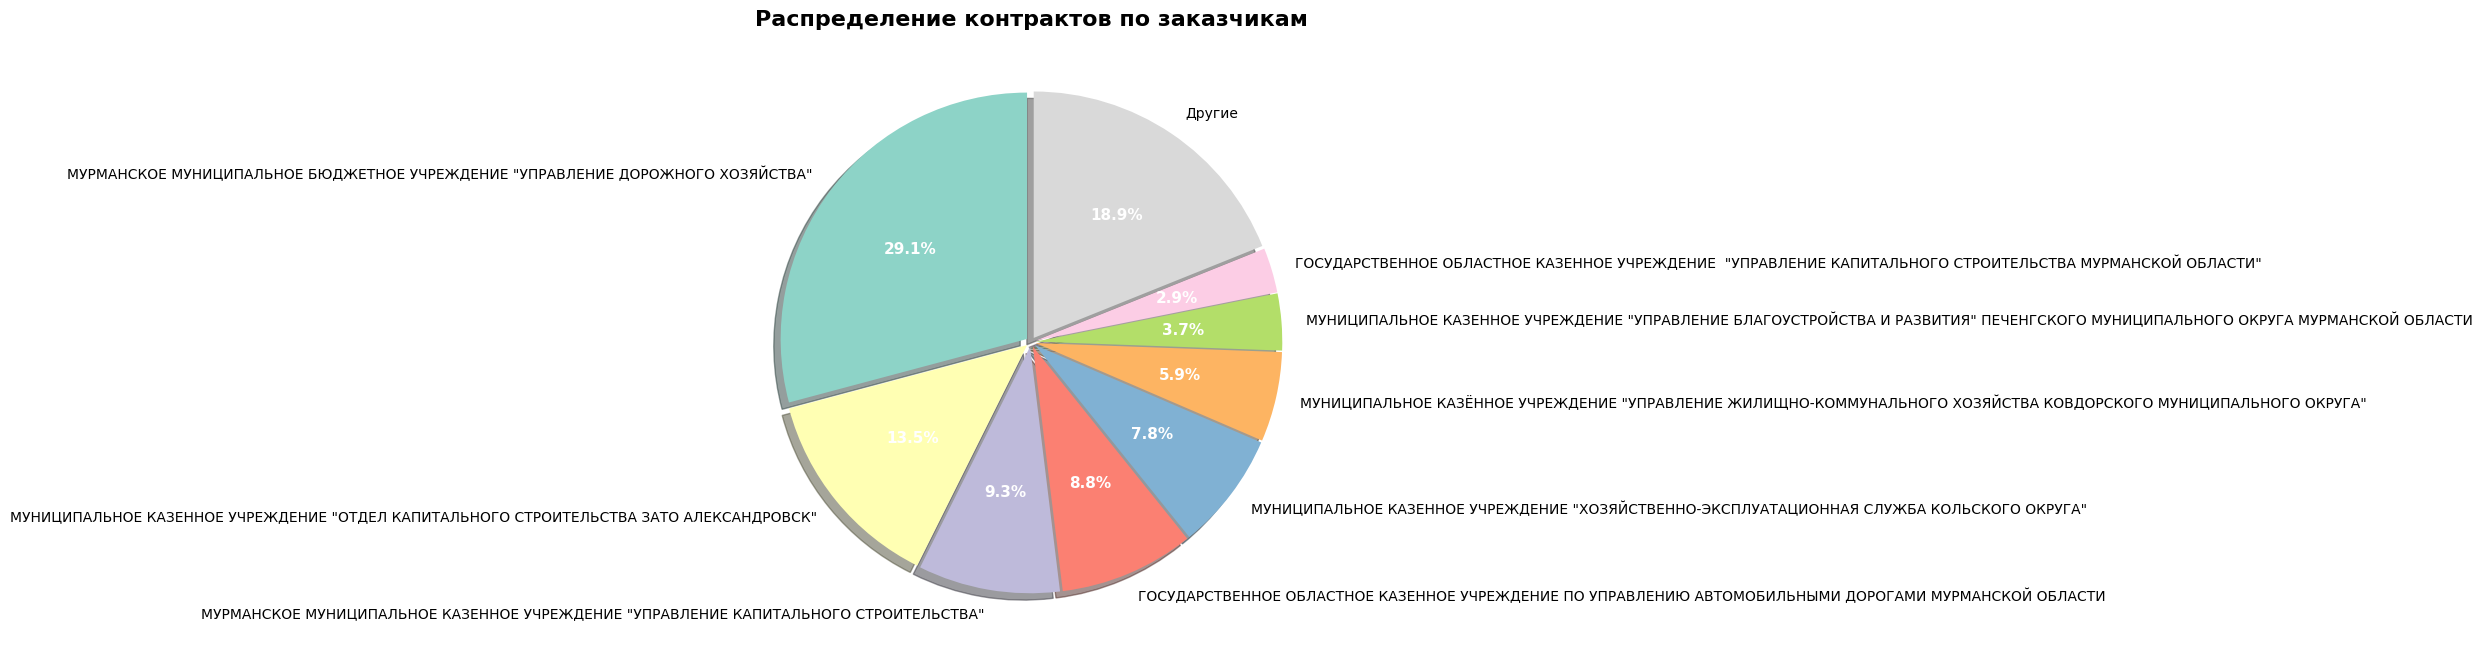

In [ ]:
# Посчитаем долю заказчиков (топ-8 + Другие)
top8 = ds['Заказчик: наименование'].value_counts().head(8)
others_count = len(ds['Заказчик: наименование']) - top8.sum()
if others_count > 0:
    top8['Другие'] = others_count

# Нормализуем
customers_pct = top8 / top8.sum()

# Настройка графики
plt.figure(figsize=(12, 8))

# Цветовая палитра (можно выбрать другую)
colors = sns.color_palette('Set3', n_colors=len(customers_pct))

# Построение с дополнительными параметрами
wedges, texts, autotexts = plt.pie(
    customers_pct,
    labels=customers_pct.index,
    colors=colors,
    autopct='%.1f%%',
    startangle=90,  # начальный угол
    explode=[0.02] * len(customers_pct),  # небольшое разделение секторов
    shadow=True,  # тень
    textprops={'fontsize': 10}
)

# Настройка текста процентов
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

plt.title("Распределение контрактов по заказчикам", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
top_suppliers = ds['Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН'].value_counts().head(10)
print("Топ-10 поставщиков по количеству контрактов:")
print(top_suppliers)

Топ-10 поставщиков по количеству контрактов:
Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН
'5190073236'      80
'510902416825'    71
'5190187794'      34
'5116000898'      33
'5102046571'      31
'5105013084'      25
'5110006364'      24
'025505212658'    24
'5190126093'      20
'510200088901'    19
Name: count, dtype: int64


In [ ]:
# Топ-10 поставщиков с ИНН и наименованиями
top10_inn = ds['Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН'].value_counts().head(10).index

# Создаем DataFrame с ИНН и названиями
top_suppliers_info = ds[ds['Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН'].isin(top10_inn)][
    ['Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН',
     'Информация о поставщиках (исполнителях, подрядчиках) по контракту: наименование юридического лица (ф.и.о. физического лица)']
].drop_duplicates()

# Добавляем количество контрактов
top_suppliers_info['Количество контрактов'] = top_suppliers_info['Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН'].map(
    ds['Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН'].value_counts()
)

# Сортируем по количеству контрактов
top_suppliers_info = top_suppliers_info.sort_values('Количество контрактов', ascending=False)
print(top_suppliers_info)

    Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН  \
167                                       '5190073236'                       
11                                      '510902416825'                       
89                                        '5190187794'                       
127                                       '5116000898'                       
69                                        '5102046571'                       
188                                       '5105013084'                       
207                                     '025505212658'                       
109                                       '5110006364'                       
612                                       '5190126093'                       
12                                      '510200088901'                       

    Информация о поставщиках (исполнителях, подрядчиках) по контракту: наименование юридического лица (ф.и.о. физического лица)  \
167   ОБЩЕ

In [ ]:
# Очищаем от кавычек, пробелов и других символов
ds['Цена контракта_число'] = (
    ds['Цена контракта']
    .astype(str)
    .str.replace(r"'", '', regex=True)  # убираем одинарные кавычки
    .str.replace(r'"', '', regex=True)  # убираем двойные кавычки
    .str.replace(' ', '')                # убираем пробелы
    .str.replace(',', '.')               # меняем запятую на точку
    .str.replace(r'[^\d.]', '', regex=True)  # оставляем только цифры и точки
    .astype(float)
)

# Теперь работает
top_suppliers_sum = ds.groupby('Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН')['Цена контракта_число'].sum().sort_values(ascending=False).head(10)
print("Топ-10 поставщиков по сумме контрактов:")
print(top_suppliers_sum)

Топ-10 поставщиков по сумме контрактов:
Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН
'510902416825'    1.236559e+10
'5190073236'      4.377023e+09
'5190187794'      3.127949e+09
'5102046571'      1.787128e+09
'5190126093'      1.430993e+09
'5116000898'      1.406492e+09
'5110006364'      1.399469e+09
'5102046317'      1.293000e+09
'5190120888'      1.282906e+09
'5105013084'      1.026356e+09
Name: Цена контракта_число, dtype: float64


Топ-10 поставщиков с долей в %:
Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН
'5190073236'      12.40
'510902416825'    11.01
'5190187794'       5.27
'5116000898'       5.12
'5102046571'       4.81
'5105013084'       3.88
'5110006364'       3.72
'025505212658'     3.72
'5190126093'       3.10
'510200088901'     2.95
Name: proportion, dtype: float64


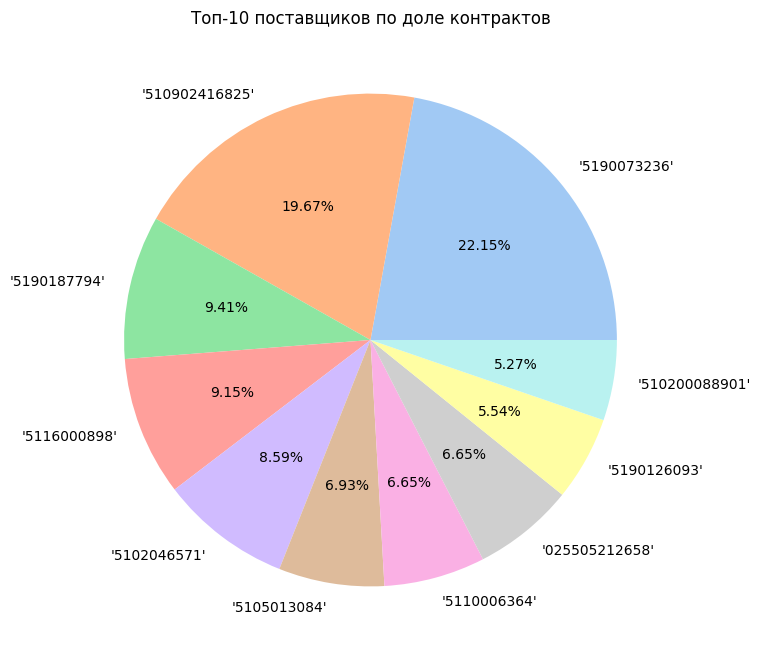

In [ ]:
# Доля каждого поставщика
supplier_pct = ds['Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН'].value_counts(normalize=True) * 100
supplier_pct = supplier_pct.round(2)

# Топ-10 с процентами
top10_pct = supplier_pct.head(10)
print("Топ-10 поставщиков с долей в %:")
print(top10_pct)

# Визуализация топ-10 в процентах
plt.figure(figsize=(10, 8))
colors = sns.color_palette('pastel')
plt.pie(top10_pct, labels=top10_pct.index, colors=colors, autopct='%.2f%%')
plt.title("Топ-10 поставщиков по доле контрактов")
plt.show()

In [ ]:
# Сохраняем топ-50 поставщиков в CSV
top50 = ds['Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН'].value_counts().head(50)

# Создаем DataFrame с информацией
top50_df = pd.DataFrame({
    'ИНН': top50.index,
    'Количество контрактов': top50.values
})

# Добавляем наименования
top50_df['Наименование'] = top50_df['ИНН'].map(
    ds.groupby('Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН')[
        'Информация о поставщиках (исполнителях, подрядчиках) по контракту: наименование юридического лица (ф.и.о. физического лица)'
    ].first()
)

# Сохраняем
top50_df.to_csv('top_suppliers.csv', index=False, encoding='utf-8-sig')
print("Топ-50 поставщиков сохранен в файл 'top_suppliers.csv'")

Топ-50 поставщиков сохранен в файл 'top_suppliers.csv'


In [ ]:
# Сначала очищаем, потом конвертируем с обработкой ошибок
ds['Цена контракта_число'] = (
    ds['Цена контракта']
    .astype(str)
    .str.replace(' ', '')                # убираем пробелы
    .str.replace(',', '.')               # меняем запятую на точку
    .str.replace(r"'", '', regex=True)   # убираем кавычки
    .str.replace(r'"', '', regex=True)   # убираем кавычки
)

# Конвертируем с обработкой ошибок (ошибки станут NaN)
ds['Цена контракта_число'] = pd.to_numeric(ds['Цена контракта_число'], errors='coerce')

# Проверяем, сколько ошибок конвертации
print(f"Количество ошибок конвертации: {ds['Цена контракта_число'].isna().sum()}")

# Удаляем строки с ошибками (или можно заполнить)
ds_clean = ds.dropna(subset=['Цена контракта_число'])

# Топ-10 поставщиков
top_suppliers_sum = ds_clean.groupby('Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН')['Цена контракта_число'].sum().sort_values(ascending=False).head(10)
print(top_suppliers_sum)

Количество ошибок конвертации: 0
Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН
'510902416825'    1.236559e+10
'5190073236'      4.377023e+09
'5190187794'      3.127949e+09
'5102046571'      1.787128e+09
'5190126093'      1.430993e+09
'5116000898'      1.406492e+09
'5110006364'      1.399469e+09
'5102046317'      1.293000e+09
'5190120888'      1.282906e+09
'5105013084'      1.026356e+09
Name: Цена контракта_число, dtype: float64


In [ ]:
# Очищаем цены
ds['Цена контракта_число'] = (
    ds['Цена контракта']
    .astype(str)
    .str.replace(r"'", '', regex=True)
    .str.replace(r'"', '', regex=True)
    .str.replace(' ', '')
    .str.replace(',', '.')
    .str.replace(r'[^\d.]', '', regex=True)
)

# Конвертируем
ds['Цена контракта_число'] = pd.to_numeric(ds['Цена контракта_число'], errors='coerce')

# Создаем таблицу с топ-поставщиками по сумме
top_suppliers = (
    ds.groupby('Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН')
    .agg({
        'Информация о поставщиках (исполнителях, подрядчиках) по контракту: наименование юридического лица (ф.и.о. физического лица)': 'first',
        'Цена контракта_число': ['sum', 'count', 'mean']
    })
    .round(2)
)

# Переименовываем колонки
top_suppliers.columns = ['Наименование', 'Общая сумма', 'Количество контрактов', 'Средняя сумма']

# Сортируем по общей сумме
top_suppliers = top_suppliers.sort_values('Общая сумма', ascending=False)

# Показываем топ-10
print("Топ-10 поставщиков по общей сумме контрактов:")
print(top_suppliers.head(10))

Топ-10 поставщиков по общей сумме контрактов:
                                                                                         Наименование  \
Информация о поставщиках (исполнителях, подрядч...                                                      
'510902416825'                                                                  КОСТИН ЮРЬЕВИЧ МАКСИМ   
'5190073236'                                         ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "ГАГАТ"   
'5190187794'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "СЕВЕ...   
'5102046571'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "МУРМ...   
'5190126093'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "АКВА...   
'5116000898'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "ТРАН...   
'5110006364'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "СЕВЕ...   
'51020463

Топ-10 поставщиков по общей сумме контрактов:
                                                                                         Наименование  \
Информация о поставщиках (исполнителях, подрядч...                                                      
'510902416825'                                                                  КОСТИН ЮРЬЕВИЧ МАКСИМ   
'5190073236'                                         ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "ГАГАТ"   
'5190187794'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "СЕВЕ...   
'5102046571'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "МУРМ...   
'5190126093'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "АКВА...   
'5116000898'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "ТРАН...   
'5110006364'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "СЕВЕ...   
'51020463

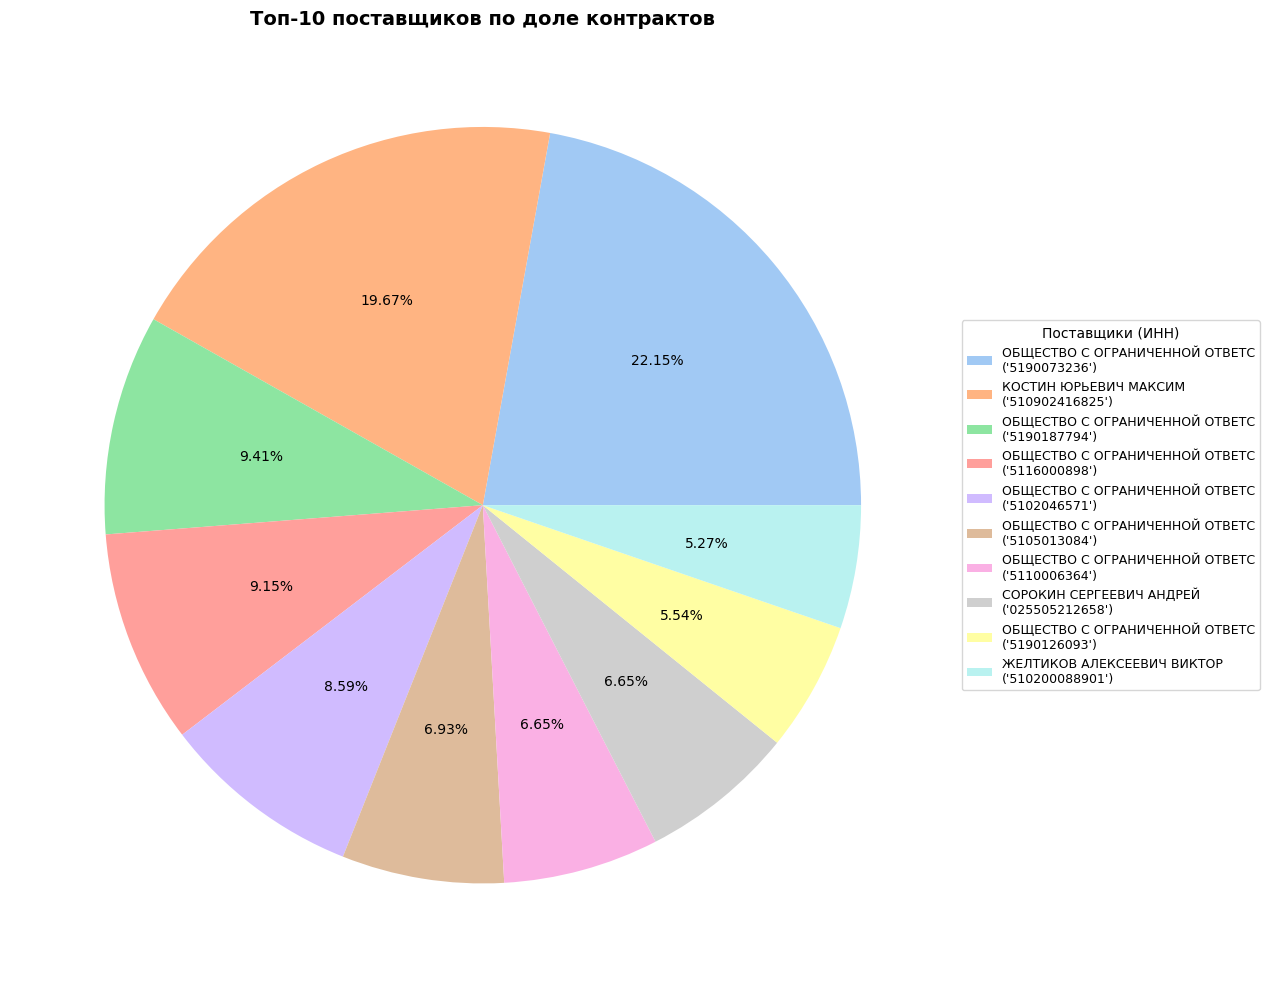

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Очищаем и конвертируем цены
ds['Цена контракта_число'] = (
    ds['Цена контракта']
    .astype(str)
    .str.replace(r"'", '', regex=True)
    .str.replace(r'"', '', regex=True)
    .str.replace(' ', '')
    .str.replace(',', '.')
    .str.replace(r'[^\d.]', '', regex=True)
)

# Конвертируем
ds['Цена контракта_число'] = pd.to_numeric(ds['Цена контракта_число'], errors='coerce')

# 2. Создаем таблицу с топ-поставщиками по сумме
top_suppliers = (
    ds.groupby('Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН')
    .agg({
        'Информация о поставщиках (исполнителях, подрядчиках) по контракту: наименование юридического лица (ф.и.о. физического лица)': 'first',
        'Цена контракта_число': ['sum', 'count', 'mean']
    })
    .round(2)
)

# Переименовываем колонки
top_suppliers.columns = ['Наименование', 'Общая сумма', 'Количество контрактов', 'Средняя сумма']

# Сортируем по общей сумме
top_suppliers = top_suppliers.sort_values('Общая сумма', ascending=False)

# Показываем топ-10
print("Топ-10 поставщиков по общей сумме контрактов:")
print(top_suppliers.head(10))

# 3. Создаем данные для круговой диаграммы
# Доля каждого поставщика
supplier_pct = ds['Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН'].value_counts(normalize=True) * 100
supplier_pct = supplier_pct.round(2)

# Топ-10 с процентами
top10_pct = supplier_pct.head(10)

# СОЗДАЕМ top10_pct_df (этот шаг был пропущен!)
top10_pct_df = pd.DataFrame({
    'ИНН': top10_pct.index,
    'Доля_процентов': top10_pct.values
})

# Добавляем наименования
top10_pct_df['Наименование'] = top10_pct_df['ИНН'].map(
    ds.groupby('Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН')[
        'Информация о поставщиках (исполнителях, подрядчиках) по контракту: наименование юридического лица (ф.и.о. физического лица)'
    ].first()
)

# Создаем подписи: ИНН + Название (сокращенное для читаемости)
top10_pct_df['Метка'] = top10_pct_df['ИНН'] + '\n' + top10_pct_df['Наименование'].str[:30]

print("\nТоп-10 поставщиков с долей в % (с названиями):")
print(top10_pct_df[['ИНН', 'Наименование', 'Доля_процентов']])

# 4. Визуализация с легендой (Ваш вариант с ошибкой, теперь исправлен)
plt.figure(figsize=(12, 10))

# Создаем подписи: Название (ИНН) для легенды
labels_legend = top10_pct_df['Наименование'].str[:30] + '\n(' + top10_pct_df['ИНН'] + ')'

colors = sns.color_palette('pastel')

# Строим круговую диаграмму с легендой
plt.pie(
    top10_pct_df['Доля_процентов'],
    labels=None,  # не показываем на самой диаграмме
    colors=colors,
    autopct='%.2f%%'
)

# Добавляем легенду
plt.legend(
    labels_legend,
    title="Поставщики (ИНН)",
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=9
)

plt.title("Топ-10 поставщиков по доле контрактов", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6947/3182921650.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


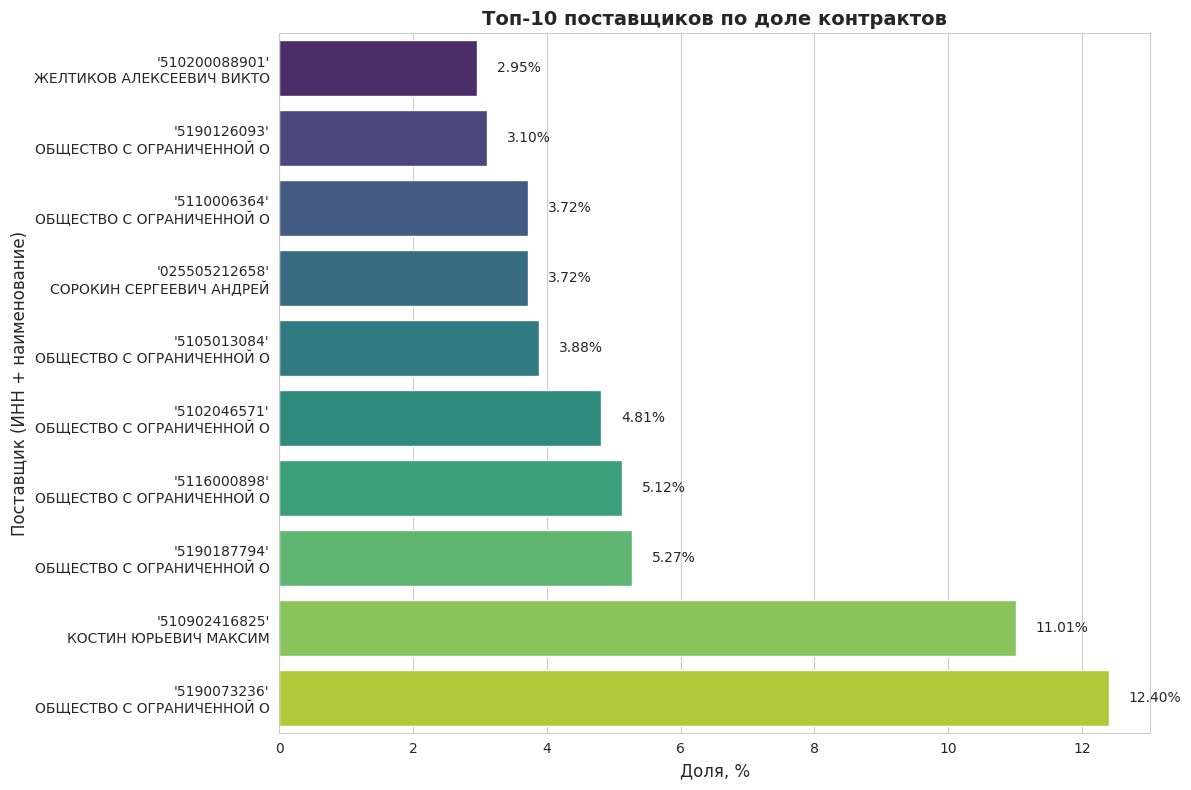

In [ ]:
# Горизонтальная гистограмма - лучше читается при длинных названиях
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')

# Сортируем для гистограммы
top10_pct_sorted = top10_pct_df.sort_values('Доля_процентов', ascending=True)

# Создаем подписи с ИНН и названием
labels = top10_pct_sorted['ИНН'] + '\n' + top10_pct_sorted['Наименование'].str[:25]

# Строим горизонтальную гистограмму
ax = sns.barplot(
    x='Доля_процентов',
    y=labels,
    data=top10_pct_sorted,
    palette='viridis'
)

# Добавляем значения
for i, v in enumerate(top10_pct_sorted['Доля_процентов']):
    ax.text(v + 0.3, i, f'{v:.2f}%', va='center', fontsize=10)

plt.title("Топ-10 поставщиков по доле контрактов", fontsize=14, fontweight='bold')
plt.xlabel("Доля, %", fontsize=12)
plt.ylabel("Поставщик (ИНН + наименование)", fontsize=12)
plt.tight_layout()
plt.show()

Топ-10 поставщиков по общей сумме контрактов:
                                                                                         Наименование  \
Информация о поставщиках (исполнителях, подрядч...                                                      
'510902416825'                                                                  КОСТИН ЮРЬЕВИЧ МАКСИМ   
'5190073236'                                         ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "ГАГАТ"   
'5190187794'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "СЕВЕ...   
'5102046571'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "МУРМ...   
'5190126093'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "АКВА...   
'5116000898'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "ТРАН...   
'5110006364'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "СЕВЕ...   
'51020463

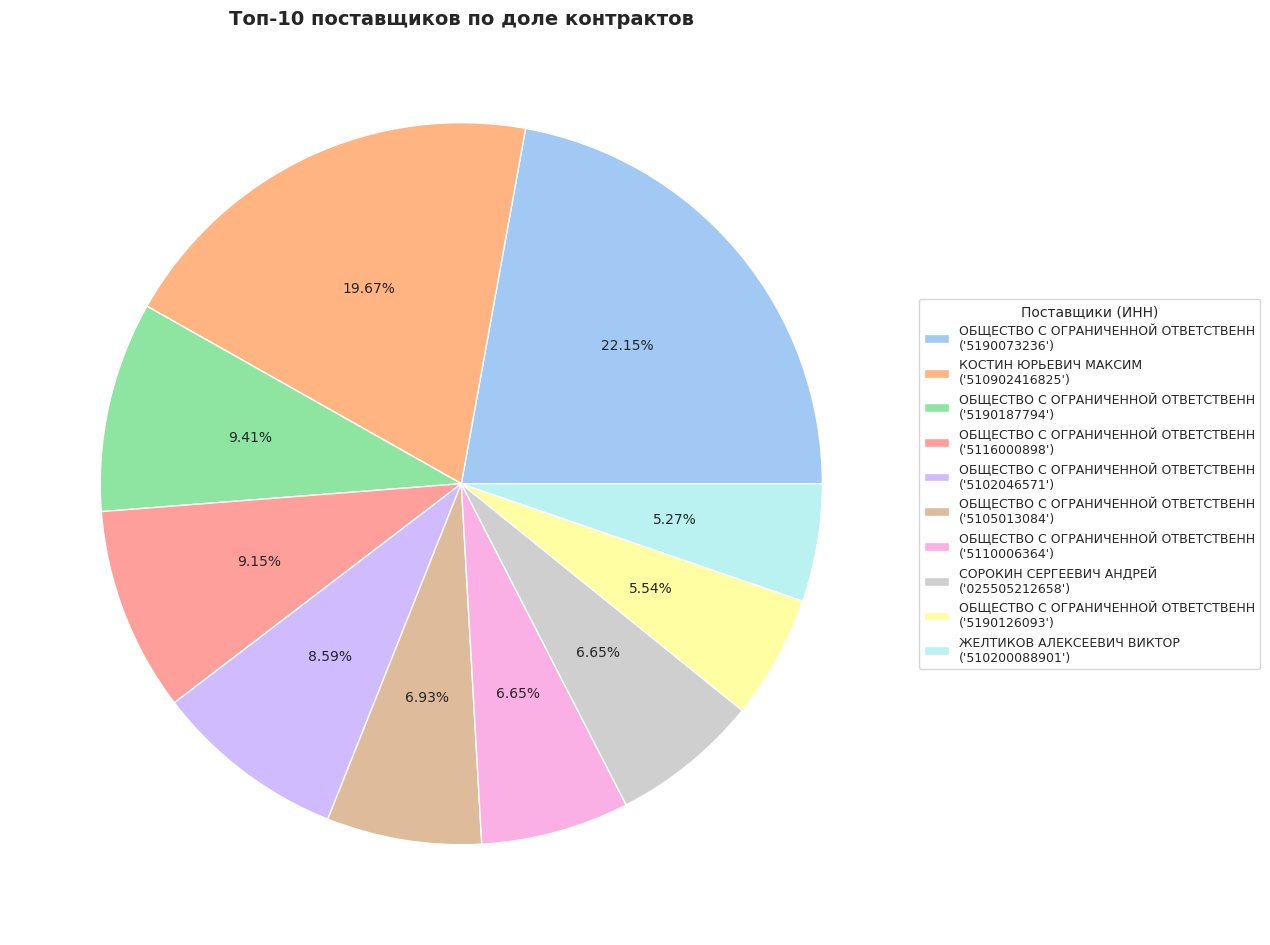

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Очищаем и конвертируем цены
ds['Цена контракта_число'] = (
    ds['Цена контракта']
    .astype(str)
    .str.replace(r"'", '', regex=True)
    .str.replace(r'"', '', regex=True)
    .str.replace(' ', '')
    .str.replace(',', '.')
    .str.replace(r'[^\d.]', '', regex=True)
)

# Конвертируем
ds['Цена контракта_число'] = pd.to_numeric(ds['Цена контракта_число'], errors='coerce')

# 2. Создаем таблицу с топ-поставщиками по сумме
top_suppliers = (
    ds.groupby('Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН')
    .agg({
        'Информация о поставщиках (исполнителях, подрядчиках) по контракту: наименование юридического лица (ф.и.о. физического лица)': 'first',
        'Цена контракта_число': ['sum', 'count', 'mean']
    })
    .round(2)
)

# Переименовываем колонки
top_suppliers.columns = ['Наименование', 'Общая сумма', 'Количество контрактов', 'Средняя сумма']

# Сортируем по общей сумме
top_suppliers = top_suppliers.sort_values('Общая сумма', ascending=False)

# Показываем топ-10
print("Топ-10 поставщиков по общей сумме контрактов:")
print(top_suppliers.head(10))

# 3. Создаем данные для круговой диаграммы
# Доля каждого поставщика
supplier_pct = ds['Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН'].value_counts(normalize=True) * 100
supplier_pct = supplier_pct.round(2)

# Топ-10 с процентами
top10_pct = supplier_pct.head(10)

# СОЗДАЕМ top10_pct_df
top10_pct_df = pd.DataFrame({
    'ИНН': top10_pct.index,
    'Доля_процентов': top10_pct.values
})

# Добавляем наименования
top10_pct_df['Наименование'] = top10_pct_df['ИНН'].map(
    ds.groupby('Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН')[
        'Информация о поставщиках (исполнителях, подрядчиках) по контракту: наименование юридического лица (ф.и.о. физического лица)'
    ].first()
)

# Функция для сокращения названий организаций
def shorten_name(name):
    """Сокращает длинные названия организаций"""
    if pd.isna(name):
        return name
    name = str(name)
    # Заменяем полные названия на сокращения
    name = name.replace('Общество с ограниченной ответственностью', 'ООО')
    name = name.replace('Акционерное общество', 'АО')
    name = name.replace('Публичное акционерное общество', 'ПАО')
    name = name.replace('Закрытое акционерное общество', 'ЗАО')
    name = name.replace('Открытое акционерное общество', 'ОАО')
    name = name.replace('Индивидуальный предприниматель', 'ИП')
    name = name.replace('Муниципальное унитарное предприятие', 'МУП')
    name = name.replace('Государственное унитарное предприятие', 'ГУП')
    name = name.replace('Федеральное государственное унитарное предприятие', 'ФГУП')
    name = name.replace('Муниципальное казенное учреждение', 'МКУ')
    name = name.replace('Государственное казенное учреждение', 'ГКУ')
    name = name.replace('Муниципальное бюджетное учреждение', 'МБУ')
    name = name.replace('Государственное бюджетное учреждение', 'ГБУ')
    return name

# Применяем функцию сокращения к наименованиям
top10_pct_df['Наименование_сокращенное'] = top10_pct_df['Наименование'].apply(shorten_name)

# Создаем подписи: ИНН + Название (сокращенное)
top10_pct_df['Метка'] = top10_pct_df['ИНН'] + '\n' + top10_pct_df['Наименование_сокращенное'].str[:35]

print("\nТоп-10 поставщиков с долей в % (с сокращенными названиями):")
print(top10_pct_df[['ИНН', 'Наименование_сокращенное', 'Доля_процентов']])

# 4. Визуализация с легендой (с сокращенными названиями)
plt.figure(figsize=(12, 10))

# Создаем подписи для легенды с сокращенными названиями
labels_legend = top10_pct_df['Наименование_сокращенное'].str[:35] + '\n(' + top10_pct_df['ИНН'] + ')'

colors = sns.color_palette('pastel')

# Строим круговую диаграмму с легендой
plt.pie(
    top10_pct_df['Доля_процентов'],
    labels=None,  # не показываем на самой диаграмме
    colors=colors,
    autopct='%.2f%%'
)

# Добавляем легенду
plt.legend(
    labels_legend,
    title="Поставщики (ИНН)",
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=9
)

plt.title("Топ-10 поставщиков по доле контрактов", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_6947/2920127995.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


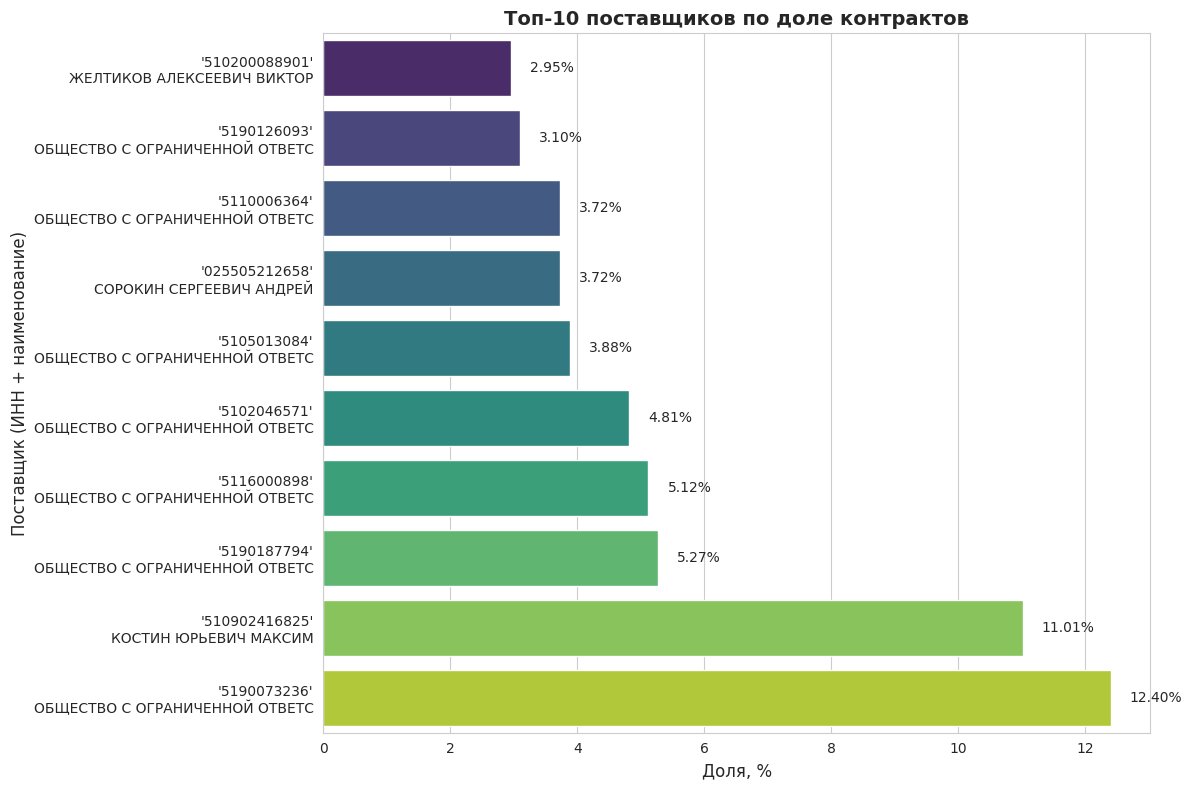

In [ ]:
# Горизонтальная гистограмма с сокращенными названиями
plt.figure(figsize=(12, 8))
sns.set_style('whitegrid')

# Сортируем для гистограммы
top10_pct_sorted = top10_pct_df.sort_values('Доля_процентов', ascending=True)

# Создаем подписи с ИНН и сокращенным названием
labels = top10_pct_sorted['ИНН'] + '\n' + top10_pct_sorted['Наименование_сокращенное'].str[:30]

# Строим горизонтальную гистограмму
ax = sns.barplot(
    x='Доля_процентов',
    y=labels,
    data=top10_pct_sorted,
    palette='viridis'
)

# Добавляем значения
for i, v in enumerate(top10_pct_sorted['Доля_процентов']):
    ax.text(v + 0.3, i, f'{v:.2f}%', va='center', fontsize=10)

plt.title("Топ-10 поставщиков по доле контрактов", fontsize=14, fontweight='bold')
plt.xlabel("Доля, %", fontsize=12)
plt.ylabel("Поставщик (ИНН + наименование)", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Расширенная функция сокращения
def shorten_name_extended(name):
    """Сокращает длинные названия организаций"""
    if pd.isna(name):
        return name
    name = str(name)

    # Словарь замен
    replacements = {
        'Общество с ограниченной ответственностью': 'ООО',
        'Акционерное общество': 'АО',
        'Публичное акционерное общество': 'ПАО',
        'Закрытое акционерное общество': 'ЗАО',
        'Открытое акционерное общество': 'ОАО',
        'Индивидуальный предприниматель': 'ИП',
        'Муниципальное унитарное предприятие': 'МУП',
        'Государственное унитарное предприятие': 'ГУП',
        'Федеральное государственное унитарное предприятие': 'ФГУП',
        'Муниципальное казенное учреждение': 'МКУ',
        'Государственное казенное учреждение': 'ГКУ',
        'Муниципальное бюджетное учреждение': 'МБУ',
        'Государственное бюджетное учреждение': 'ГБУ',
        'Федеральное государственное бюджетное учреждение': 'ФГБУ',
        'Федеральное государственное казенное учреждение': 'ФГКУ',
        'Общество с ограниченной ответственностью': 'ООО',
    }

    for full, short in replacements.items():
        name = name.replace(full, short)

    # Убираем лишние пробелы
    name = ' '.join(name.split())

    return name

# Применяем расширенную функцию
top10_pct_df['Наименование_сокращенное'] = top10_pct_df['Наименование'].apply(shorten_name_extended)

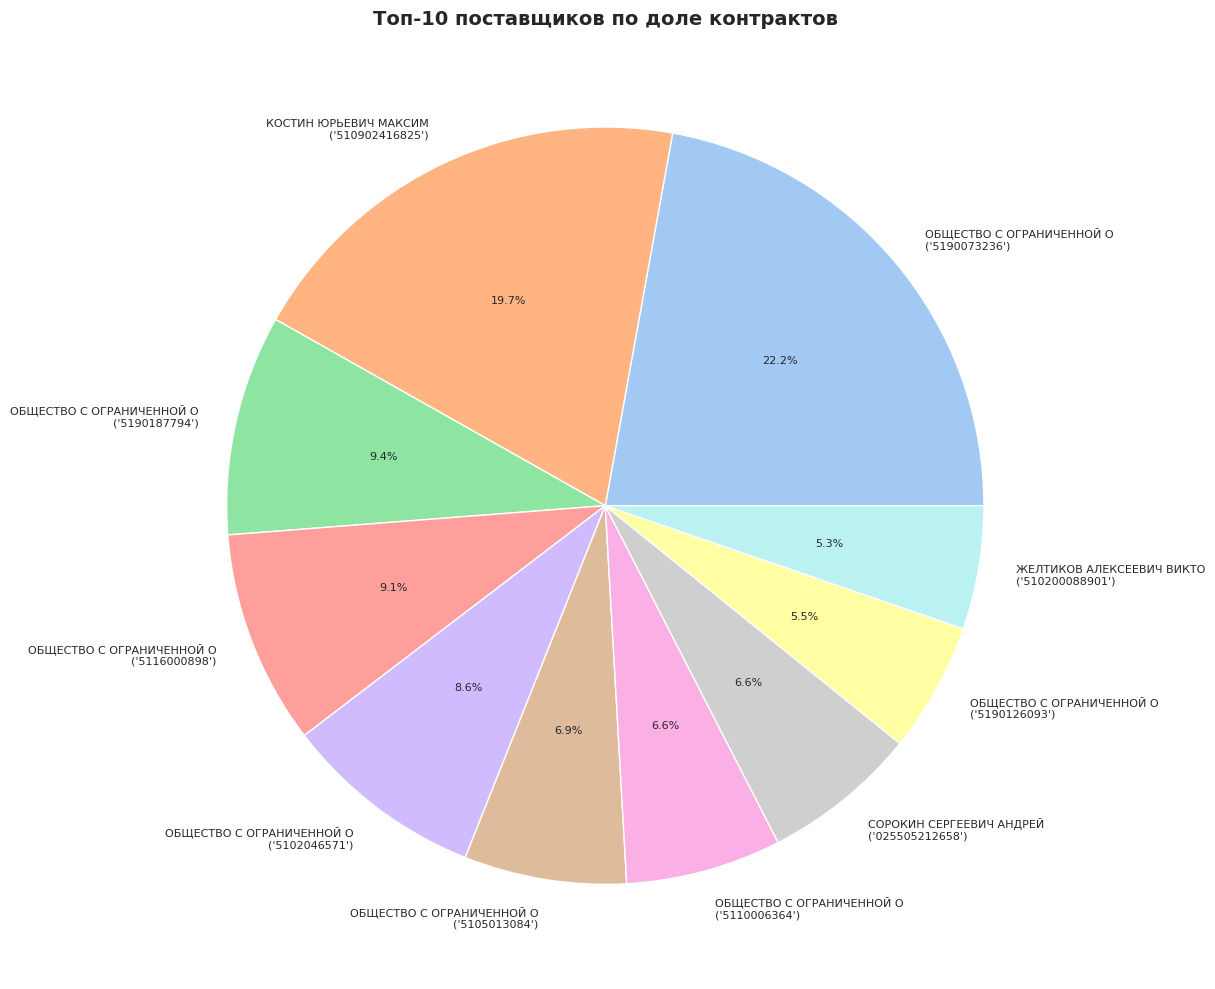

In [ ]:
# Круговая диаграмма с подписями на секторах (сокращенные названия)
plt.figure(figsize=(12, 10))

# Создаем короткие подписи для отображения на диаграмме
labels_short = top10_pct_df['Наименование_сокращенное'].str[:25] + '\n(' + top10_pct_df['ИНН'] + ')'

colors = sns.color_palette('pastel')

# Строим круговую диаграмму с подписями
plt.pie(
    top10_pct_df['Доля_процентов'],
    labels=labels_short,  # подписи на диаграмме
    colors=colors,
    autopct='%.1f%%',
    textprops={'fontsize': 8}
)

plt.title("Топ-10 поставщиков по доле контрактов", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Топ-10 поставщиков по общей сумме контрактов:
                                                                                         Наименование  \
Информация о поставщиках (исполнителях, подрядч...                                                      
'510902416825'                                                                  КОСТИН ЮРЬЕВИЧ МАКСИМ   
'5190073236'                                         ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "ГАГАТ"   
'5190187794'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "СЕВЕ...   
'5102046571'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "МУРМ...   
'5190126093'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "АКВА...   
'5116000898'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "ТРАН...   
'5110006364'                                        ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ "СЕВЕ...   
'51020463

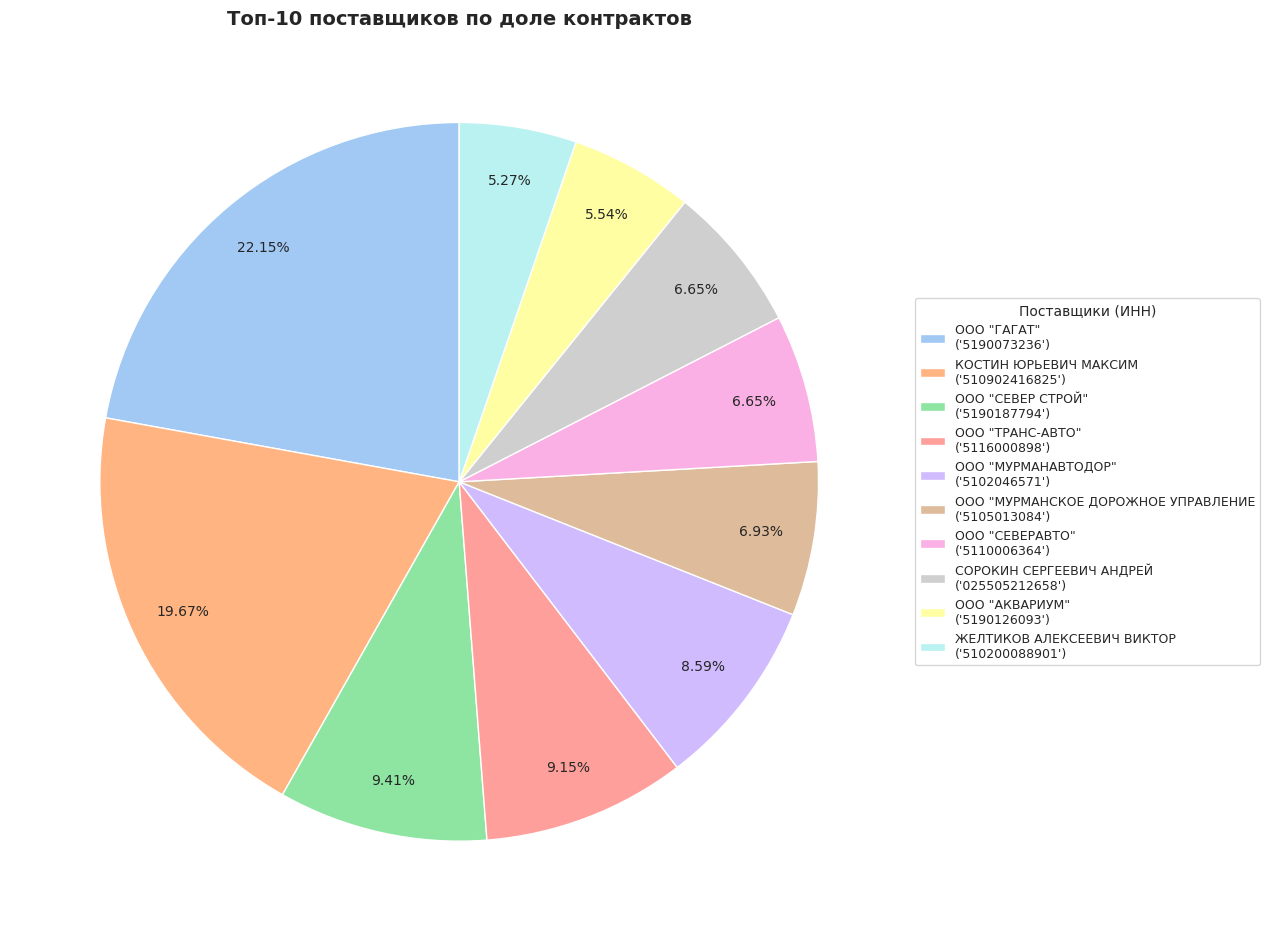

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

# 1. Очищаем и конвертируем цены
ds['Цена контракта_число'] = (
    ds['Цена контракта']
    .astype(str)
    .str.replace(r"'", '', regex=True)
    .str.replace(r'"', '', regex=True)
    .str.replace(' ', '')
    .str.replace(',', '.')
    .str.replace(r'[^\d.]', '', regex=True)
)

ds['Цена контракта_число'] = pd.to_numeric(ds['Цена контракта_число'], errors='coerce')

# 2. Создаем таблицу с топ-поставщиками по сумме
top_suppliers = (
    ds.groupby('Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН')
    .agg({
        'Информация о поставщиках (исполнителях, подрядчиках) по контракту: наименование юридического лица (ф.и.о. физического лица)': 'first',
        'Цена контракта_число': ['sum', 'count', 'mean']
    })
    .round(2)
)

top_suppliers.columns = ['Наименование', 'Общая сумма', 'Количество контрактов', 'Средняя сумма']
top_suppliers = top_suppliers.sort_values('Общая сумма', ascending=False)

print("Топ-10 поставщиков по общей сумме контрактов:")
print(top_suppliers.head(10))

# 3. Создаем данные для визуализации
supplier_pct = ds['Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН'].value_counts(normalize=True) * 100
supplier_pct = supplier_pct.round(2)
top10_pct = supplier_pct.head(10)

top10_pct_df = pd.DataFrame({
    'ИНН': top10_pct.index,
    'Доля_процентов': top10_pct.values
})

# Добавляем наименования
top10_pct_df['Наименование'] = top10_pct_df['ИНН'].map(
    ds.groupby('Информация о поставщиках (исполнителях, подрядчиках) по контракту: ИНН')[
        'Информация о поставщиках (исполнителях, подрядчиках) по контракту: наименование юридического лица (ф.и.о. физического лица)'
    ].first()
)

# УЛУЧШЕННАЯ функция для сокращения названий (учитывает разные регистры)
def shorten_name(name):
    """Сокращает длинные названия организаций с учетом разных вариантов написания"""
    if pd.isna(name):
        return name
    name = str(name)

    # Словарь замен с учетом разных регистров (используем регулярные выражения)
    replacements = [
        # Общество с ограниченной ответственностью (все варианты)
        (r'ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ', 'ООО'),
        (r'Общество с ограниченной ответственностью', 'ООО'),
        (r'общество с ограниченной ответственностью', 'ООО'),
        (r'Общество с ограниченной ответственностью "', 'ООО "'),
        (r'ООО "', 'ООО "'),

        # Акционерное общество
        (r'АКЦИОНЕРНОЕ ОБЩЕСТВО', 'АО'),
        (r'Акционерное общество', 'АО'),
        (r'акционерное общество', 'АО'),

        # Публичное акционерное общество
        (r'ПУБЛИЧНОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО', 'ПАО'),
        (r'Публичное акционерное общество', 'ПАО'),
        (r'публичное акционерное общество', 'ПАО'),

        # Закрытое акционерное общество
        (r'ЗАКРЫТОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО', 'ЗАО'),
        (r'Закрытое акционерное общество', 'ЗАО'),
        (r'закрытое акционерное общество', 'ЗАО'),

        # Открытое акционерное общество
        (r'ОТКРЫТОЕ АКЦИОНЕРНОЕ ОБЩЕСТВО', 'ОАО'),
        (r'Открытое акционерное общество', 'ОАО'),
        (r'открытое акционерное общество', 'ОАО'),

        # Индивидуальный предприниматель
        (r'ИНДИВИДУАЛЬНЫЙ ПРЕДПРИНИМАТЕЛЬ', 'ИП'),
        (r'Индивидуальный предприниматель', 'ИП'),
        (r'индивидуальный предприниматель', 'ИП'),

        # Муниципальное унитарное предприятие
        (r'МУНИЦИПАЛЬНОЕ УНИТАРНОЕ ПРЕДПРИЯТИЕ', 'МУП'),
        (r'Муниципальное унитарное предприятие', 'МУП'),
        (r'муниципальное унитарное предприятие', 'МУП'),

        # Государственное унитарное предприятие
        (r'ГОСУДАРСТВЕННОЕ УНИТАРНОЕ ПРЕДПРИЯТИЕ', 'ГУП'),
        (r'Государственное унитарное предприятие', 'ГУП'),
        (r'государственное унитарное предприятие', 'ГУП'),

        # Федеральное государственное унитарное предприятие
        (r'ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ УНИТАРНОЕ ПРЕДПРИЯТИЕ', 'ФГУП'),
        (r'Федеральное государственное унитарное предприятие', 'ФГУП'),
        (r'федеральное государственное унитарное предприятие', 'ФГУП'),

        # Муниципальное казенное учреждение
        (r'МУНИЦИПАЛЬНОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ', 'МКУ'),
        (r'Муниципальное казенное учреждение', 'МКУ'),
        (r'муниципальное казенное учреждение', 'МКУ'),

        # Государственное казенное учреждение
        (r'ГОСУДАРСТВЕННОЕ КАЗЕННОЕ УЧРЕЖДЕНИЕ', 'ГКУ'),
        (r'Государственное казенное учреждение', 'ГКУ'),
        (r'государственное казенное учреждение', 'ГКУ'),

        # Муниципальное бюджетное учреждение
        (r'МУНИЦИПАЛЬНОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ', 'МБУ'),
        (r'Муниципальное бюджетное учреждение', 'МБУ'),
        (r'муниципальное бюджетное учреждение', 'МБУ'),

        # Государственное бюджетное учреждение
        (r'ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ', 'ГБУ'),
        (r'Государственное бюджетное учреждение', 'ГБУ'),
        (r'государственное бюджетное учреждение', 'ГБУ'),

        # Федеральное государственное бюджетное учреждение
        (r'ФЕДЕРАЛЬНОЕ ГОСУДАРСТВЕННОЕ БЮДЖЕТНОЕ УЧРЕЖДЕНИЕ', 'ФГБУ'),
        (r'Федеральное государственное бюджетное учреждение', 'ФГБУ'),
        (r'федеральное государственное бюджетное учреждение', 'ФГБУ'),
    ]

    for pattern, replacement in replacements:
        name = re.sub(pattern, replacement, name)

    return name

# Применяем функцию сокращения
top10_pct_df['Наименование_сокращенное'] = top10_pct_df['Наименование'].apply(shorten_name)

print("\nТоп-10 поставщиков с долей в % (с сокращенными названиями):")
print(top10_pct_df[['ИНН', 'Наименование', 'Наименование_сокращенное', 'Доля_процентов']])

# 4. Визуализация с легендой
plt.figure(figsize=(12, 10))

# Создаем подписи для легенды
labels_legend = top10_pct_df['Наименование_сокращенное'].str[:35] + '\n(' + top10_pct_df['ИНН'] + ')'

colors = sns.color_palette('pastel')

plt.pie(
    top10_pct_df['Доля_процентов'],
    labels=None,
    colors=colors,
    autopct='%.2f%%',
    pctdistance=0.85,
    startangle=90
)

plt.legend(
    labels_legend,
    title="Поставщики (ИНН)",
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=9
)

plt.title("Топ-10 поставщиков по доле контрактов", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Функция для классификации видов работ
def classify_work_type(description):
    """
    Классифицирует вид работ на основе описания объекта закупки
    """
    if pd.isna(description):
        return 'Не определено'

    desc = str(description).lower()

    # Строительство и ремонт дорог
    if any(keyword in desc for keyword in [
        'дорог', 'дорож', 'тротуар', 'асфальт', 'покрытие дорож',
        'ремонт дор', 'строительство дор', 'автомобильн', 'магистрал',
        'проезд', 'улиц', 'мост', 'путепровод', 'разметка'
    ]):
        return 'Строительство и ремонт дорог'

    # Строительство и ремонт зданий (капитальный)
    elif any(keyword in desc for keyword in [
        'капитальный ремонт здан', 'капремонт здан', 'строительство здан',
        'реконструкция здан', 'капитальн ремонт', 'кап. ремонт',
        'многоквартирн', 'мкд', 'фасад', 'кровл', 'крыш',
        'ремонт крыш', 'ремонт фасад', 'замена лифт', 'подвал'
    ]):
        return 'Капитальный ремонт зданий'

    # Текущий ремонт помещений
    elif any(keyword in desc for keyword in [
        'текущий ремонт', 'ремонт помещен', 'ремонт кабинет',
        'ремонт класс', 'ремонт групп', 'отделочн', 'косметическ',
        'ремонт коридор', 'ремонт комнат', 'ремонт санузл',
        'обои', 'покраска', 'штукатурк'
    ]):
        return 'Текущий ремонт помещений'

    # Строительство и ремонт инженерных сетей
    elif any(keyword in desc for keyword in [
        'теплосет', 'водопровод', 'канализация', 'электроснабжен',
        'газоснабжен', 'вентиляция', 'отопление', 'котельн',
        'инженерн сет', 'ремонт труб', 'замена труб', 'водоснабжен',
        'кабель', 'электрощит', 'трансформатор'
    ]):
        return 'Ремонт инженерных сетей'

    # Проектные и изыскательские работы
    elif any(keyword in desc for keyword in [
        'проектн', 'изыскательск', 'проектирован', 'пнир',
        'разработка проект', 'инженерн изыскания', 'пдс'
    ]):
        return 'Проектные работы'

    # Строительство новых объектов
    elif any(keyword in desc for keyword in [
        'новое строительство', 'строительство объект', 'возведени',
        'строительство здани', 'стройка', 'новострой'
    ]):
        return 'Новое строительство'

    # Поставка строительных материалов
    elif any(keyword in desc for keyword in [
        'строительн материал', 'стройматериал', 'цемент', 'песок',
        'щебень', 'кирпич', 'бетон', 'арматура', 'пиломатериал'
    ]):
        return 'Поставка материалов'

    # Благоустройство территории
    elif any(keyword in desc for keyword in [
        'благоустройств', 'озеленен', 'дорожк', 'скамейк',
        'урн', 'освещен', 'детск площадк'
    ]):
        return 'Благоустройство'

    else:
        return 'Другое'

# Применяем функцию к столбцу
ds['Вид работ'] = ds['Объект закупки: наименование товаров, работ, услуг'].apply(classify_work_type)

# Проверяем результат
print("Распределение по видам работ:")
print(ds['Вид работ'].value_counts())
print("\nВ процентах:")
print(ds['Вид работ'].value_counts(normalize=True) * 100)

Распределение по видам работ:
Вид работ
Строительство и ремонт дорог    317
Другое                          240
Благоустройство                  41
Капитальный ремонт зданий        41
Ремонт инженерных сетей           4
Новое строительство               1
Проектные работы                  1
Name: count, dtype: int64

В процентах:
Вид работ
Строительство и ремонт дорог    49.147287
Другое                          37.209302
Благоустройство                  6.356589
Капитальный ремонт зданий        6.356589
Ремонт инженерных сетей          0.620155
Новое строительство              0.155039
Проектные работы                 0.155039
Name: proportion, dtype: float64


In [ ]:
def classify_work_type_detailed(description):
    """
    Расширенная классификация видов работ
    """
    if pd.isna(description):
        return 'Не определено'

    desc = str(description).lower()

    # Дороги
    if any(kw in desc for kw in ['дорог', 'дорож', 'тротуар', 'асфальт', 'покрытие дорож',
                                  'ремонт дор', 'строительство дор', 'автомобильн', 'магистрал',
                                  'проезд', 'улиц', 'мост', 'путепровод', 'разметка']):
        if 'капитальн' in desc or 'кап.' in desc:
            return 'Капитальный ремонт дорог'
        elif 'строительств' in desc:
            return 'Строительство дорог'
        else:
            return 'Ремонт дорог'

    # Здания - новое строительство
    elif any(kw in desc for kw in ['новое строительство', 'строительство здани', 'возведени',
                                    'строительство объект', 'новострой']):
        return 'Новое строительство зданий'

    # Здания - капитальный ремонт
    elif any(kw in desc for kw in ['капитальный ремонт здан', 'капремонт здан', 'реконструкция здан',
                                     'капитальн ремонт', 'кап. ремонт', 'многоквартирн', 'мкд',
                                     'фасад', 'кровл', 'крыш', 'ремонт крыш', 'ремонт фасад',
                                     'замена лифт']):
        return 'Капитальный ремонт зданий'

    # Текущий ремонт помещений
    elif any(kw in desc for kw in ['текущий ремонт', 'ремонт помещен', 'ремонт кабинет',
                                     'ремонт класс', 'ремонт групп', 'отделочн', 'косметическ',
                                     'ремонт коридор', 'ремонт комнат', 'ремонт санузл']):
        return 'Текущий ремонт помещений'

    # Инженерные сети
    elif any(kw in desc for kw in ['теплосет', 'водопровод', 'канализация', 'электроснабжен',
                                     'газоснабжен', 'вентиляция', 'отопление', 'котельн',
                                     'инженерн сет', 'ремонт труб', 'замена труб', 'водоснабжен',
                                     'кабель', 'электрощит']):
        return 'Ремонт инженерных сетей'

    # Проектные работы
    elif any(kw in desc for kw in ['проектн', 'изыскательск', 'проектирован', 'пнир',
                                     'разработка проект', 'инженерн изыскания', 'пдс']):
        return 'Проектные работы'

    # Поставка материалов
    elif any(kw in desc for kw in ['строительн материал', 'стройматериал', 'цемент', 'песок',
                                     'щебень', 'кирпич', 'бетон', 'арматура', 'пиломатериал']):
        return 'Поставка материалов'

    # Благоустройство
    elif any(kw in desc for kw in ['благоустройств', 'озеленен', 'дорожк', 'скамейк',
                                     'урн', 'освещен', 'детск площадк']):
        return 'Благоустройство'

    else:
        return 'Другое'

# Применяем расширенную классификацию
ds['Вид работ детальный'] = ds['Объект закупки: наименование товаров, работ, услуг'].apply(classify_work_type_detailed)

print("\nДетальное распределение по видам работ:")
print(ds['Вид работ детальный'].value_counts())


Детальное распределение по видам работ:
Вид работ детальный
Ремонт дорог                  310
Другое                        240
Благоустройство                41
Капитальный ремонт зданий      41
Капитальный ремонт дорог        7
Ремонт инженерных сетей         4
Новое строительство зданий      1
Проектные работы                1
Name: count, dtype: int64


In [ ]:
# Сначала применим базовую классификацию
def classify_work_type(description):
    """Базовая классификация видов работ"""
    if pd.isna(description):
        return 'Не определено'

    desc = str(description).lower()

    # Строительство и ремонт дорог
    if any(keyword in desc for keyword in [
        'дорог', 'дорож', 'тротуар', 'асфальт', 'покрытие дорож',
        'ремонт дор', 'строительство дор', 'автомобильн', 'магистрал',
        'проезд', 'улиц', 'мост', 'путепровод', 'разметка'
    ]):
        return 'Строительство и ремонт дорог'

    # Строительство и ремонт зданий (капитальный)
    elif any(keyword in desc for keyword in [
        'капитальный ремонт здан', 'капремонт здан', 'строительство здан',
        'реконструкция здан', 'капитальн ремонт', 'кап. ремонт',
        'многоквартирн', 'мкд', 'фасад', 'кровл', 'крыш',
        'ремонт крыш', 'ремонт фасад', 'замена лифт', 'подвал'
    ]):
        return 'Капитальный ремонт зданий'

    # Текущий ремонт помещений
    elif any(keyword in desc for keyword in [
        'текущий ремонт', 'ремонт помещен', 'ремонт кабинет',
        'ремонт класс', 'ремонт групп', 'отделочн', 'косметическ',
        'ремонт коридор', 'ремонт комнат', 'ремонт санузл',
        'обои', 'покраска', 'штукатурк'
    ]):
        return 'Текущий ремонт помещений'

    # Строительство и ремонт инженерных сетей
    elif any(keyword in desc for keyword in [
        'теплосет', 'водопровод', 'канализация', 'электроснабжен',
        'газоснабжен', 'вентиляция', 'отопление', 'котельн',
        'инженерн сет', 'ремонт труб', 'замена труб', 'водоснабжен',
        'кабель', 'электрощит', 'трансформатор'
    ]):
        return 'Ремонт инженерных сетей'

    # Проектные и изыскательские работы
    elif any(keyword in desc for keyword in [
        'проектн', 'изыскательск', 'проектирован', 'пнир',
        'разработка проект', 'инженерн изыскания', 'пдс'
    ]):
        return 'Проектные работы'

    # Строительство новых объектов
    elif any(keyword in desc for keyword in [
        'новое строительство', 'строительство объект', 'возведени',
        'строительство здани', 'стройка', 'новострой'
    ]):
        return 'Новое строительство'

    # Поставка строительных материалов
    elif any(keyword in desc for keyword in [
        'строительн материал', 'стройматериал', 'цемент', 'песок',
        'щебень', 'кирпич', 'бетон', 'арматура', 'пиломатериал'
    ]):
        return 'Поставка материалов'

    # Благоустройство территории
    elif any(keyword in desc for keyword in [
        'благоустройств', 'озеленен', 'дорожк', 'скамейк',
        'урн', 'освещен', 'детск площадк'
    ]):
        return 'Благоустройство'

    else:
        return 'Другое'

# Применяем функцию
ds['Вид работ'] = ds['Объект закупки: наименование товаров, работ, услуг'].apply(classify_work_type)

# Анализируем категорию "Другое"
other_works = ds[ds['Вид работ'] == 'Другое']['Объект закупки: наименование товаров, работ, услуг']
print(f"Всего записей в категории 'Другое': {len(other_works)}")
print("\nПримеры записей из категории 'Другое':")
for i, example in enumerate(other_works.head(20)):
    print(f"{i+1}. {example}")

Всего записей в категории 'Другое': 240

Примеры записей из категории 'Другое':
1. Камера видеонаблюдения. Товарный знак: АйТек ПРО
2. Счетчик электроэнергии. Товарный знак: Пульсар
3. Коммутатор. Товарный знак: TFortis
4. Выполнение работ по капитальному ремонту объекта капитального строительства в сфере образования
5. Выполнение работ по капитальному ремонту объекта капитального строительства в сфере образования
6. Выполнение работ по капитальному ремонту объекта капитального строительства в сфере культуры
7. Выполнение работ по капитальному ремонту объекта капитального строительства в сфере образования
8. Выполнение работ по капитальному ремонту объекта капитального строительства в сфере культуры
9. Выполнение работ по капитальному ремонту спортивного объекта
10. Выполнение работ по капитальному ремонту объекта капитального строительства в сфере образования
11. Выполнение работ по капитальному ремонту объекта капитального строительства в сфере культуры
12. Выполнение работ по ремонт

In [ ]:
# Анализируем частоту слов в категории "Другое"
from collections import Counter
import re

# Собираем все слова из категории "Другое"
all_words = []
for text in other_works:
    if pd.notna(text):
        words = re.findall(r'\b[а-яёa-z]{4,}\b', str(text).lower())
        all_words.extend(words)

# Считаем частоту слов
word_counts = Counter(all_words)
print("Топ-30 самых частых слов в категории 'Другое':")
for word, count in word_counts.most_common(30):
    print(f"  {word}: {count}")

Топ-30 самых частых слов в категории 'Другое':
  выполнение: 118
  работ: 118
  ремонту: 113
  капитальному: 106
  объекта: 102
  строительства: 99
  капитального: 98
  сфере: 98
  содержание: 96
  образования: 85
  зимнее: 48
  летнее: 48
  проезжей: 21
  части: 21
  ремонт: 20
  ливневой: 12
  канализации: 12
  подпорных: 12
  стен: 12
  лестниц: 12
  озеленительных: 12
  полос: 12
  ограждений: 12
  остановок: 12
  общественного: 12
  транспорта: 12
  автопавильонов: 12
  бортового: 12
  камня: 12
  въездов: 12


In [ ]:
def classify_work_type_extended(description):
    """
    Расширенная классификация видов работ с новыми группами
    """
    if pd.isna(description):
        return 'Не определено'

    desc = str(description).lower()

    # ===== 1. ДОРОГИ =====
    if any(keyword in desc for keyword in [
        'дорог', 'дорож', 'тротуар', 'асфальт', 'покрытие дорож',
        'ремонт дор', 'строительство дор', 'автомобильн', 'магистрал',
        'проезд', 'улиц', 'мост', 'путепровод', 'разметка'
    ]):
        return 'Строительство и ремонт дорог'

    # ===== 2. КАПИТАЛЬНЫЙ РЕМОНТ ЗДАНИЙ =====
    elif any(keyword in desc for keyword in [
        'капитальный ремонт здан', 'капремонт здан', 'реконструкция здан',
        'капитальн ремонт', 'кап. ремонт', 'многоквартирн', 'мкд',
        'фасад', 'кровл', 'крыш', 'ремонт крыш', 'ремонт фасад',
        'замена лифт', 'подвал', 'ремонт подъезд'
    ]):
        return 'Капитальный ремонт зданий'

    # ===== 3. ТЕКУЩИЙ РЕМОНТ ПОМЕЩЕНИЙ =====
    elif any(keyword in desc for keyword in [
        'текущий ремонт', 'ремонт помещен', 'ремонт кабинет',
        'ремонт класс', 'ремонт групп', 'отделочн', 'косметическ',
        'ремонт коридор', 'ремонт комнат', 'ремонт санузл',
        'обои', 'покраска', 'штукатурк', 'ремонт пол'
    ]):
        return 'Текущий ремонт помещений'

    # ===== 4. ИНЖЕНЕРНЫЕ СЕТИ =====
    elif any(keyword in desc for keyword in [
        'теплосет', 'водопровод', 'канализация', 'электроснабжен',
        'газоснабжен', 'вентиляция', 'отопление', 'котельн',
        'инженерн сет', 'ремонт труб', 'замена труб', 'водоснабжен',
        'кабель', 'электрощит', 'трансформатор', 'электромонтаж'
    ]):
        return 'Ремонт инженерных сетей'

    # ===== 5. ПРОЕКТНЫЕ РАБОТЫ =====
    elif any(keyword in desc for keyword in [
        'проектн', 'изыскательск', 'проектирован', 'пнир',
        'разработка проект', 'инженерн изыскания', 'пдс'
    ]):
        return 'Проектные работы'

    # ===== 6. НОВОЕ СТРОИТЕЛЬСТВО =====
    elif any(keyword in desc for keyword in [
        'новое строительство', 'строительство объект', 'возведени',
        'строительство здани', 'стройка', 'новострой'
    ]):
        return 'Новое строительство'

    # ===== 7. ПОСТАВКА МАТЕРИАЛОВ =====
    elif any(keyword in desc for keyword in [
        'строительн материал', 'стройматериал', 'цемент', 'песок',
        'щебень', 'кирпич', 'бетон', 'арматура', 'пиломатериал',
        'известь', 'гипс', 'краска', 'лак', 'эмаль'
    ]):
        return 'Поставка материалов'

    # ===== 8. БЛАГОУСТРОЙСТВО =====
    elif any(keyword in desc for keyword in [
        'благоустройств', 'озеленен', 'дорожк', 'скамейк',
        'урн', 'освещен', 'детск площадк', 'газон'
    ]):
        return 'Благоустройство'

    # ===== НОВЫЕ ГРУППЫ =====

    # 9. Ремонт и обслуживание оборудования
    elif any(keyword in desc for keyword in [
        'ремонт оборудован', 'обслуживание оборуд', 'станок', 'механизм',
        'ремонт техник', 'диагностик', 'наладк', 'пусконаладк',
        'ремонт машин', 'экскаватор', 'бульдозер', 'кран'
    ]):
        return 'Ремонт оборудования'

    # 10. Демонтажные работы
    elif any(keyword in desc for keyword in [
        'демонтаж', 'снос', 'разборк', 'ликвидац', 'срезк'
    ]):
        return 'Демонтажные работы'

    # 11. Охрана труда и безопасность
    elif any(keyword in desc for keyword in [
        'охрана труд', 'безопасность', 'пожарн', 'огнезащит',
        'эвакуаци', 'сигнализаци', 'видеонаблюдени', 'контроль доступ',
        'проверк', 'испытани', 'защит', 'средство защит'
    ]):
        return 'Охрана труда и безопасность'

    # 12. Ландшафтные работы
    elif any(keyword in desc for keyword in [
        'ландшафт', 'дерев', 'кустарник', 'цветник', 'клумб',
        'посадк', 'обрезк', 'вырубк', 'спил'
    ]):
        return 'Ландшафтные работы'

    # 13. Мусороудаление и клининг
    elif any(keyword in desc for keyword in [
        'мусор', 'вывоз мусор', 'уборк', 'клининг', 'чистк',
        'дезинфекци', 'дезинсекци', 'дератизаци'
    ]):
        return 'Мусороудаление и уборка'

    # 14. Услуги спецтехники
    elif any(keyword in desc for keyword in [
        'экскаватор', 'бульдозер', 'кран', 'автовышк', 'автогидроподъемник',
        'трактор', 'погрузчик', 'самосвал', 'техник', 'спецтехник'
    ]):
        return 'Услуги спецтехники'

    # 15. Экспертиза и оценка
    elif any(keyword in desc for keyword in [
        'экспертиз', 'оценк', 'обследовани', 'техническ диагностик',
        'аудит', 'консультировани'
    ]):
        return 'Экспертиза и оценка'

    # 16. Пусконаладочные работы
    elif any(keyword in desc for keyword in [
        'пусконаладк', 'наладк', 'испытани', 'ввод в эксплуатаци',
        'проверк оборудован'
    ]):
        return 'Пусконаладочные работы'

    # 17. Ремонт мебели и интерьера
    elif any(keyword in desc for keyword in [
        'мебель', 'шкаф', 'стол', 'стул', 'кресл', 'диван',
        'изготовлени мебель', 'ремонт мебель'
    ]):
        return 'Ремонт мебели и интерьера'

    # 18. Ремонт окон и дверей
    elif any(keyword in desc for keyword in [
        'окн', 'двер', 'остеклен', 'витраж', 'стеклопакет',
        'дверной блок', 'оконный блок'
    ]):
        return 'Ремонт окон и дверей'

    # 19. Автомобильные работы
    elif any(keyword in desc for keyword in [
        'автомобиль', 'автотранспорт', 'машин', 'гараж', 'ремонт авто'
    ]):
        return 'Автомобильные работы'

    # 20. Строительный надзор
    elif any(keyword in desc for keyword in [
        'строительный надзор', 'технический надзор', 'авторский надзор',
        'контроль качеств', 'строительный контроль'
    ]):
        return 'Строительный надзор'

    # 21. Санитарные работы
    elif any(keyword in desc for keyword in [
        'санитарн', 'гигиен', 'обработк', 'дезинфекц', 'чистк'
    ]):
        return 'Санитарные работы'

    # 22. Работы с металлом
    elif any(keyword in desc for keyword in [
        'металлоконструкци', 'сварк', 'металлообработк', 'ковк',
        'металлическ', 'профиль', 'арматурн'
    ]):
        return 'Работы с металлом'

    # 23. Бетонные работы
    elif any(keyword in desc for keyword in [
        'бетонирован', 'бетонн', 'стяжк', 'фундамент', 'монолитн'
    ]):
        return 'Бетонные работы'

    # 24. Кровельные работы
    elif any(keyword in desc for keyword in [
        'кровельн', 'кровл', 'крыш', 'гидроизоляци', 'мягк кровл'
    ]):
        return 'Кровельные работы'

    else:
        return 'Другое'

In [ ]:
# Применяем расширенную классификацию
ds['Вид работ расширенный'] = ds['Объект закупки: наименование товаров, работ, услуг'].apply(classify_work_type_extended)

# Смотрим распределение
print("Распределение по видам работ (расширенная классификация):")
work_counts_extended = ds['Вид работ расширенный'].value_counts()
print(work_counts_extended)

print("\nВ процентах:")
print((ds['Вид работ расширенный'].value_counts(normalize=True) * 100).round(2))

# Проверяем, что осталось в категории "Другое"
other_works_extended = ds[ds['Вид работ расширенный'] == 'Другое']['Объект закупки: наименование товаров, работ, услуг']
print(f"\nОсталось в категории 'Другое': {len(other_works_extended)} записей")
print("\nПримеры оставшихся записей:")
for example in other_works_extended.head(10):
    print(f"  - {example}")

Распределение по видам работ (расширенная классификация):
Вид работ расширенный
Строительство и ремонт дорог    317
Другое                          238
Благоустройство                  41
Капитальный ремонт зданий        41
Ремонт инженерных сетей           4
Новое строительство               1
Охрана труда и безопасность       1
Проектные работы                  1
Демонтажные работы                1
Name: count, dtype: int64

В процентах:
Вид работ расширенный
Строительство и ремонт дорог    49.15
Другое                          36.90
Благоустройство                  6.36
Капитальный ремонт зданий        6.36
Ремонт инженерных сетей          0.62
Новое строительство              0.16
Охрана труда и безопасность      0.16
Проектные работы                 0.16
Демонтажные работы               0.16
Name: proportion, dtype: float64

Осталось в категории 'Другое': 238 записей

Примеры оставшихся записей:
  - Счетчик электроэнергии. Товарный знак: Пульсар
  - Коммутатор. Товарный знак: TFor

Шаг 1: Создаем целевую классификацию с приоритетом на нужные объекты

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

def classify_target_works(description):
    """
    Классификация с акцентом на капитальный ремонт зданий
    образования, культуры и спортивных объектов
    """
    if pd.isna(description):
        return 'Другое (не целевое)'

    desc = str(description).lower()

    # ===== ПРИОРИТЕТНЫЕ ОБЪЕКТЫ =====

    # 1. КАПИТАЛЬНЫЙ РЕМОНТ ЗДАНИЙ ОБРАЗОВАНИЯ
    education_keywords = ['школ', 'детск сад', 'доу', 'гимнази', 'лицей', 'колледж',
                          'техникум', 'училищ', 'университет', 'институт', 'академи',
                          'образовательн', 'учебн', 'корпус', 'общеобразовательн',
                          'средн школ', 'начальн школ', 'коррекционн школ']

    if any(kw in desc for kw in education_keywords):
        if any(kw in desc for kw in ['капитальн', 'кап. ремонт', 'капремонт', 'реконструкц']):
            return 'Капремонт: Образование'
        else:
            return 'Образование (не капремонт)'

    # 2. КАПИТАЛЬНЫЙ РЕМОНТ ЗДАНИЙ КУЛЬТУРЫ
    culture_keywords = ['культур', 'дк', 'дворец культур', 'клуб', 'библиотек',
                        'музей', 'театр', 'кинотеатр', 'филармони', 'выставочн',
                        'концертн', 'дом культур', 'центр культур']

    if any(kw in desc for kw in culture_keywords):
        if any(kw in desc for kw in ['капитальн', 'кап. ремонт', 'капремонт', 'реконструкц']):
            return 'Капремонт: Культура'
        else:
            return 'Культура (не капремонт)'

    # 3. КАПИТАЛЬНЫЙ РЕМОНТ СПОРТИВНЫХ ОБЪЕКТОВ
    sport_keywords = ['спорт', 'стадион', 'бассейн', 'спортзал', 'спортивн зал',
                      'физкультурн', 'спорткомплекс', 'спортплощадк', 'ледов',
                      'каток', 'арен', 'манеж', 'спортивн сооруж', 'тренажерн']

    if any(kw in desc for kw in sport_keywords):
        if any(kw in desc for kw in ['капитальн', 'кап. ремонт', 'капремонт', 'реконструкц']):
            return 'Капремонт: Спорт'
        else:
            return 'Спорт (не капремонт)'

    # ===== ИСКЛЮЧАЕМ НЕЦЕЛЕВЫЕ КАТЕГОРИИ =====

    # Дороги
    road_keywords = ['дорог', 'дорож', 'тротуар', 'асфальт', 'разметк', 'мост',
                     'путепровод', 'автомобильн', 'магистрал', 'проезд', 'улиц']
    if any(kw in desc for kw in road_keywords):
        return 'Исключено: Дороги'

    # Материалы
    material_keywords = ['строительн материал', 'стройматериал', 'цемент', 'песок',
                         'щебень', 'кирпич', 'бетон', 'арматура', 'пиломатериал',
                         'краска', 'известь', 'гипс', 'лак', 'эмаль']
    if any(kw in desc for kw in material_keywords):
        return 'Исключено: Материалы'

    # Благоустройство (если не связано с капремонтом)
    if any(kw in desc for kw in ['благоустройств', 'озеленен', 'скамейк', 'урн']):
        return 'Исключено: Благоустройство'

    # Инженерные сети (если отдельно, не в составе капремонта)
    if any(kw in desc for kw in ['теплосет', 'водопровод', 'канализация', 'отопление']):
        if not any(kw in desc for kw in ['капитальн', 'кап. ремонт', 'капремонт']):
            return 'Исключено: Инженерные сети'

    # ===== ЕСЛИ НЕ ПОДОШЛО НИ ОДНО УСЛОВИЕ =====
    return 'Другое (не целевое)'

# Применяем классификацию
ds['Целевая классификация'] = ds['Объект закупки: наименование товаров, работ, услуг'].apply(classify_target_works)

# Смотрим результаты
print("Распределение по целевой классификации:")
print(ds['Целевая классификация'].value_counts())
print("\nВ процентах:")
print((ds['Целевая классификация'].value_counts(normalize=True) * 100).round(2))

Распределение по целевой классификации:
Целевая классификация
Исключено: Дороги             302
Другое (не целевое)           277
Спорт (не капремонт)           19
Капремонт: Культура            16
Исключено: Благоустройство     12
Культура (не капремонт)         8
Образование (не капремонт)      5
Капремонт: Спорт                3
Капремонт: Образование          3
Name: count, dtype: int64

В процентах:
Целевая классификация
Исключено: Дороги             46.82
Другое (не целевое)           42.95
Спорт (не капремонт)           2.95
Капремонт: Культура            2.48
Исключено: Благоустройство     1.86
Культура (не капремонт)        1.24
Образование (не капремонт)     0.78
Капремонт: Спорт               0.47
Капремонт: Образование         0.47
Name: proportion, dtype: float64


In [ ]:
# Создаем датафрейм только с капитальным ремонтом целевых объектов
target_categories = ['Капремонт: Образование', 'Капремонт: Культура', 'Капремонт: Спорт']
df_target = ds[ds['Целевая классификация'].isin(target_categories)].copy()

print(f"Всего записей в датафрейме: {len(ds)}")
print(f"Записей по целевым объектам: {len(df_target)}")
print(f"Доля целевых объектов: {len(df_target)/len(ds)*100:.2f}%")

# Смотрим распределение по типам объектов
print("\nРаспределение по типам объектов капремонта:")
print(df_target['Целевая классификация'].value_counts())

Всего записей в датафрейме: 645
Записей по целевым объектам: 22
Доля целевых объектов: 3.41%

Распределение по типам объектов капремонта:
Целевая классификация
Капремонт: Культура       16
Капремонт: Спорт           3
Капремонт: Образование     3
Name: count, dtype: int64


In [ ]:
# Анализ по каждому типу объектов
for category in target_categories:
    print(f"\n{'='*60}")
    print(f"АНАЛИЗ: {category}")
    print('='*60)

    cat_data = df_target[df_target['Целевая классификация'] == category]

    print(f"Количество контрактов: {len(cat_data)}")
    print(f"Общая сумма: {cat_data['Цена контракта_число'].sum():,.2f} руб.")
    print(f"Средняя сумма: {cat_data['Цена контракта_число'].mean():,.2f} руб.")
    print(f"Минимальная сумма: {cat_data['Цена контракта_число'].min():,.2f} руб.")
    print(f"Максимальная сумма: {cat_data['Цена контракта_число'].max():,.2f} руб.")

    print("\nТоп-5 объектов закупки:")
    for obj in cat_data['Объект закупки: наименование товаров, работ, услуг'].head(5):
        print(f"  - {obj}")

    print("\nТоп-5 заказчиков:")
    for customer, count in cat_data['Заказчик: наименование'].value_counts().head(5).items():
        print(f"  - {customer}: {count} контрактов")

    print("\nТоп-5 поставщиков:")
    for supplier, count in cat_data['Информация о поставщиках (исполнителях, подрядчиках) по контракту: наименование юридического лица (ф.и.о. физического лица)'].value_counts().head(5).items():
        print(f"  - {supplier[:50]}: {count} контрактов")


АНАЛИЗ: Капремонт: Образование
Количество контрактов: 3
Общая сумма: 260,409,085.38 руб.
Средняя сумма: 86,803,028.46 руб.
Минимальная сумма: 86,803,028.46 руб.
Максимальная сумма: 86,803,028.46 руб.

Топ-5 объектов закупки:
  - Выполнение работ по комплексному капитальному ремонту помещений Заозерского гарнизонного военного суда и постоянного судебного присутствия в г. Заозерске Кольского районного суда Мурманской области, расположенных по адресу: Мурманская область,  г. Заозерск, пер. Школьный, д. 6. (этап: 01.01.2026 – 30.10.2026)
  - Выполнение работ по комплексному капитальному ремонту помещений Заозерского гарнизонного военного суда и постоянного судебного присутствия в г. Заозерске Кольского районного суда Мурманской области, расположенных по адресу: Мурманская область,  г. Заозерск, пер. Школьный, д. 6. (этап: с момента подписания Контракта – 15.12.2025)
  - Выполнение работ по комплексному капитальному ремонту помещений Заозерского гарнизонного военного суда и постоянного суд

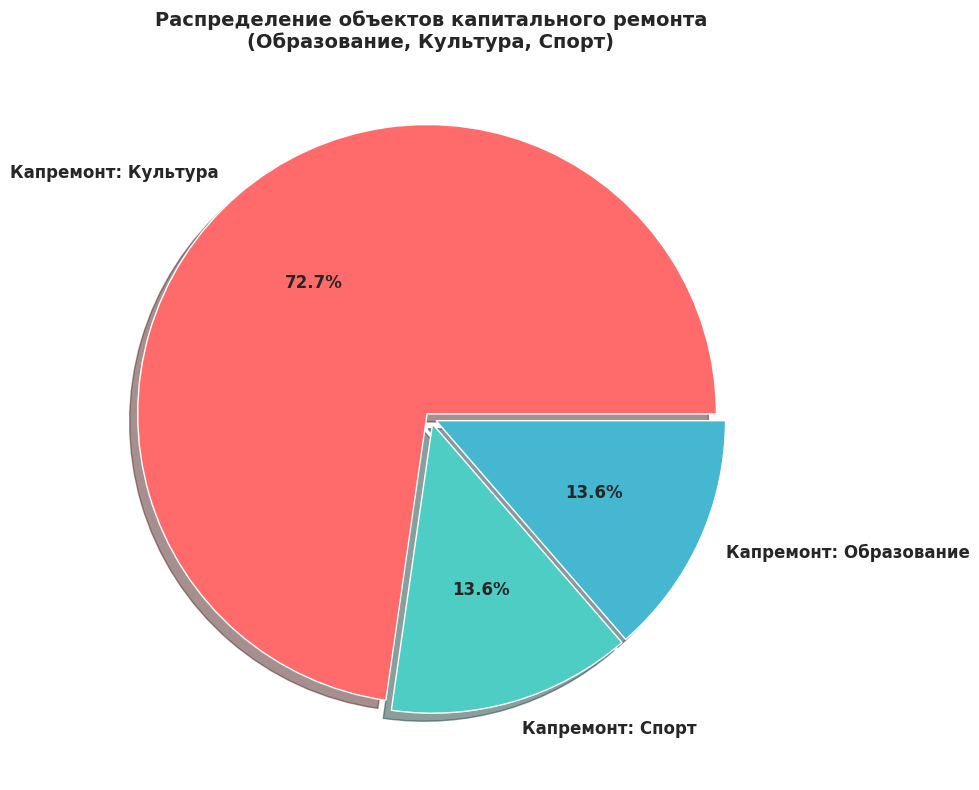

/tmp/ipykernel_6947/3058072753.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])


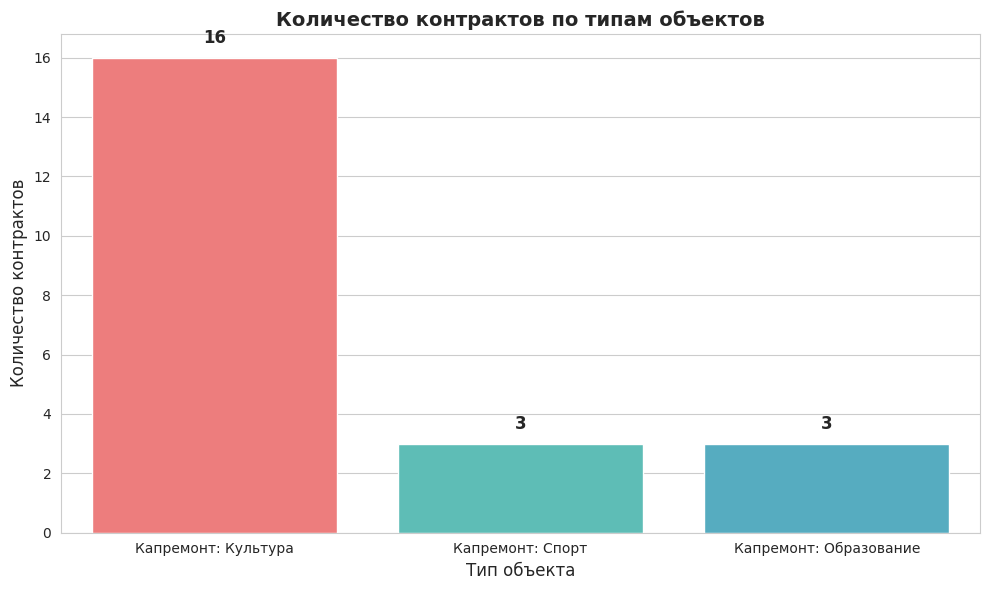

In [ ]:
# 4.1 Распределение по типам объектов (круговая диаграмма)
plt.figure(figsize=(10, 8))

target_counts = df_target['Целевая классификация'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # Красный, зеленый, синий

plt.pie(
    target_counts,
    labels=target_counts.index,
    colors=colors,
    autopct='%.1f%%',
    explode=[0.02, 0.02, 0.02],
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title('Распределение объектов капитального ремонта\n(Образование, Культура, Спорт)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4.2 Сравнение количества контрактов по типам
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])

for i, v in enumerate(target_counts.values):
    ax.text(i, v + 0.5, str(v), ha='center', fontsize=12, fontweight='bold')

plt.title('Количество контрактов по типам объектов', fontsize=14, fontweight='bold')
plt.xlabel('Тип объекта', fontsize=12)
plt.ylabel('Количество контрактов', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6947/2181245949.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Целевая классификация', y='Цена контракта_число', data=df_target, palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])


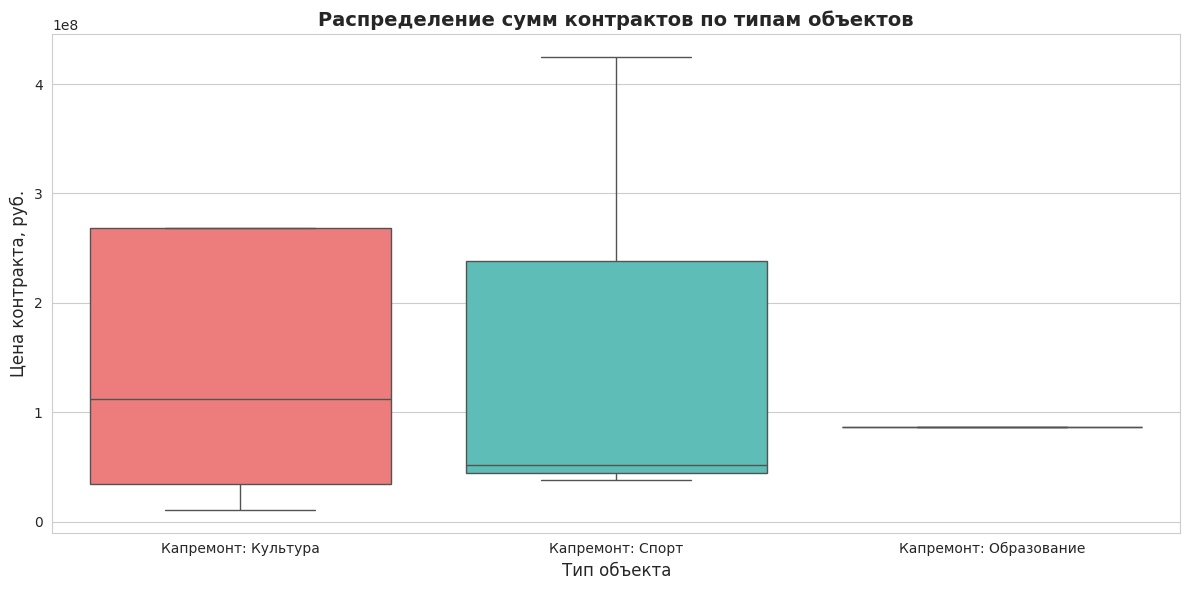

/tmp/ipykernel_6947/2181245949.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=total_sums.values / 1000000, y=total_sums.index, palette=['#45B7D1', '#4ECDC4', '#FF6B6B'])


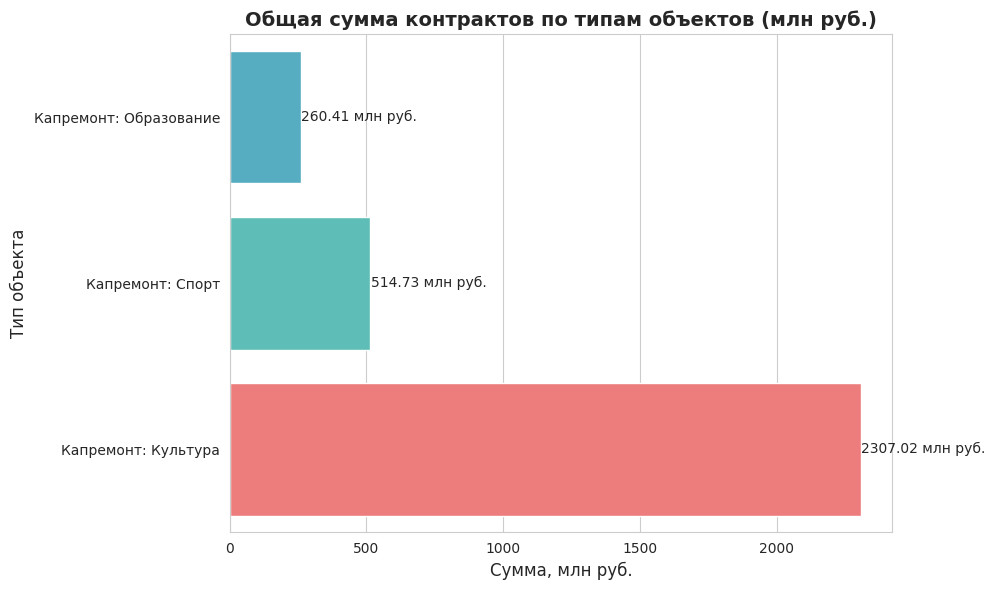

In [ ]:
# 5.1 Сравнение сумм контрактов
plt.figure(figsize=(12, 6))

# Создаем boxplot для сравнения распределения сумм
sns.boxplot(x='Целевая классификация', y='Цена контракта_число', data=df_target, palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Распределение сумм контрактов по типам объектов', fontsize=14, fontweight='bold')
plt.xlabel('Тип объекта', fontsize=12)
plt.ylabel('Цена контракта, руб.', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 5.2 Общая сумма по типам объектов
plt.figure(figsize=(10, 6))

total_sums = df_target.groupby('Целевая классификация')['Цена контракта_число'].sum().sort_values(ascending=True)

ax = sns.barplot(x=total_sums.values / 1000000, y=total_sums.index, palette=['#45B7D1', '#4ECDC4', '#FF6B6B'])

for i, v in enumerate(total_sums.values / 1000000):
    ax.text(v + 0.5, i, f'{v:.2f} млн руб.', va='center', fontsize=10)

plt.title('Общая сумма контрактов по типам объектов (млн руб.)', fontsize=14, fontweight='bold')
plt.xlabel('Сумма, млн руб.', fontsize=12)
plt.ylabel('Тип объекта', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# 6.1 Топ-10 объектов закупки в целевой выборке
print("Топ-10 объектов закупки (капремонт образования, культуры, спорта):")
top_objects = df_target['Объект закупки: наименование товаров, работ, услуг'].value_counts().head(10)
for i, (obj, count) in enumerate(top_objects.items(), 1):
    print(f"{i}. {obj[:100]}{'...' if len(obj) > 100 else ''} ({count})")

# 6.2 Топ-10 заказчиков
print("\nТоп-10 заказчиков капитального ремонта:")
top_customers = df_target['Заказчик: наименование'].value_counts().head(10)
for i, (customer, count) in enumerate(top_customers.items(), 1):
    print(f"{i}. {customer[:80]}... ({count} контрактов)")

# 6.3 Топ-10 поставщиков
print("\nТоп-10 поставщиков капитального ремонта:")
top_suppliers = df_target['Информация о поставщиках (исполнителях, подрядчиках) по контракту: наименование юридического лица (ф.и.о. физического лица)'].value_counts().head(10)
for i, (supplier, count) in enumerate(top_suppliers.items(), 1):
    print(f"{i}. {supplier[:80]}... ({count} контрактов)")

Топ-10 объектов закупки (капремонт образования, культуры, спорта):
1. Выполнение работ по капитальному ремонту объекта капитального строительства в сфере культуры (8)
2. Выполнение работ по капитальному ремонту спортивного объекта (3)
3. Выполнение работ по комплексному капитальному ремонту помещений Заозерского гарнизонного военного су... (1)
4. Выполнение работ по комплексному капитальному ремонту помещений Заозерского гарнизонного военного су... (1)
5. Выполнение работ по комплексному капитальному ремонту помещений Заозерского гарнизонного военного су... (1)
6. Капитальный ремонт 75 квартир в многоквартирном доме для семей военнослужащих по ул. Небольсина, д. ... (1)
7. Капитальный ремонт 75 квартир в многоквартирном доме для семей военнослужащих по ул. Небольсина, д. ... (1)
8. Капитальный ремонт 75 квартир в многоквартирном доме для семей военнослужащих по ул. Небольсина, д. ... (1)
9. Капитальный ремонт 100 квартир в многоквартирном доме для семей военнослужащих по ул. Небольсина


Распределение по муниципалитетам:
Муниципалитет
Другой муниципалитет    18
г. Заозерск              3
г. Североморск           1
Name: count, dtype: int64


/tmp/ipykernel_6947/2104759542.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=mun_counts.values, y=mun_counts.index, palette='viridis')


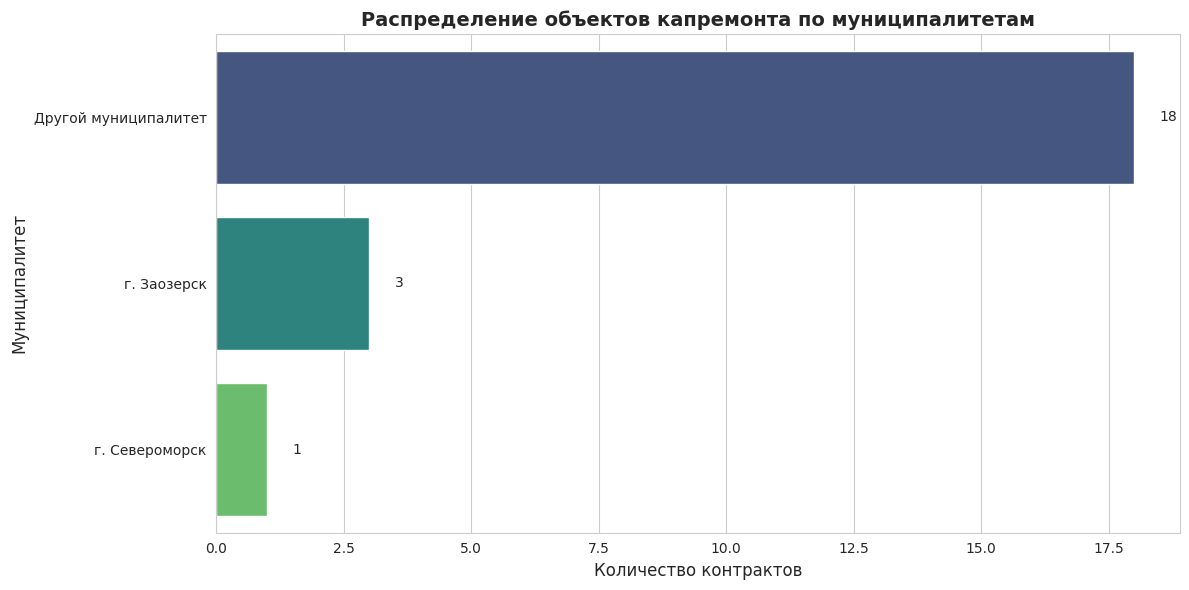

In [ ]:
# Если есть данные по муниципалитетам или адресам
if 'Объект закупки: наименование товаров, работ, услуг' in df_target.columns:
    # Пытаемся извлечь муниципалитет из описания
    def extract_municipality(text):
        if pd.isna(text):
            return 'Не указан'
        text = str(text)
        # Поиск по шаблонам (можно расширить)
        patterns = [
            r'г\.?\s*Мурманск',
            r'г\.?\s*Апатиты',
            r'г\.?\s*Североморск',
            r'г\.?\s*Мончегорск',
            r'г\.?\s*Кандалакша',
            r'г\.?\s*Кировск',
            r'г\.?\s*Оленегорск',
            r'г\.?\s*Полярный',
            r'г\.?\s*Заозерск',
            r'г\.?\s*Полярные Зори'
        ]
        for pattern in patterns:
            if re.search(pattern, text, re.IGNORECASE):
                return re.search(pattern, text, re.IGNORECASE).group(0)
        return 'Другой муниципалитет'

    df_target['Муниципалитет'] = df_target['Объект закупки: наименование товаров, работ, услуг'].apply(extract_municipality)

    print("\nРаспределение по муниципалитетам:")
    print(df_target['Муниципалитет'].value_counts())

    # Визуализация по муниципалитетам
    plt.figure(figsize=(12, 6))
    mun_counts = df_target['Муниципалитет'].value_counts()
    ax = sns.barplot(x=mun_counts.values, y=mun_counts.index, palette='viridis')
    for i, v in enumerate(mun_counts.values):
        ax.text(v + 0.5, i, str(v), va='center', fontsize=10)
    plt.title('Распределение объектов капремонта по муниципалитетам', fontsize=14, fontweight='bold')
    plt.xlabel('Количество контрактов', fontsize=12)
    plt.ylabel('Муниципалитет', fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
# Сохраняем целевой датафрейм в Excel для дальнейшего анализа
df_target.to_excel('kapremont_obrazovanie_kultura_sport.xlsx', index=False)
print("Целевой датафрейм сохранен в файл 'kapremont_obrazovanie_kultura_sport.xlsx'")

# Сохраняем сводную статистику
summary_stats = df_target.groupby('Целевая классификация').agg({
    'Цена контракта_число': ['count', 'sum', 'mean', 'min', 'max']
}).round(2)

summary_stats.columns = ['Количество', 'Общая сумма', 'Средняя сумма', 'Минимум', 'Максимум']
summary_stats.to_excel('summary_kapremont.xlsx')
print("Сводная статистика сохранена в файл 'summary_kapremont.xlsx'")

Целевой датафрейм сохранен в файл 'kapremont_obrazovanie_kultura_sport.xlsx'
Сводная статистика сохранена в файл 'summary_kapremont.xlsx'
